In [1]:
import pandas as pd
import numpy as np

csv_filename = "data/data.csv"

# provera da ispravno pravimo data.csv fajl od polaznih fajlova koji predstavljaju dataset kako bi olaksali upotrebu i manipulaciju dataset-om
df = pd.read_csv(csv_filename)
print(df.head())

print("Provera broja NaN/null vrednosti:")
print(df.isna().sum().sum())

print("Provera broja inf vrednosti za numericke atribute:")
print(np.isinf(df.select_dtypes(include=np.number)).sum().sum())

print("Provera broja redova i kolona: ")
print(df.shape)

print("Provera broja subjekata i balansiranosti podataka po subjektu: ")
print(df[["subject_id", "target"]].value_counts())

print("Provera balansiranosti klasa: ")
print(df["target"].value_counts())

print("Provera broja atributa po vrsti merenja:")
print(f"ECG: {df.columns.str.startswith("ECG").sum()}")
print(f"TIB: {df.columns.str.startswith("IT").sum()}")
print(f"EDA arm: {df.columns.str.startswith("EDA_Arm").sum()}")
print(f"EDA hand: {df.columns.str.startswith("EDA_Hand").sum()}")

   subject_id  ECG_original_mean  ECG_original_std  ECG_original_trimmean25  \
0           1          -0.004125          0.254095                 0.001426   
1           1           0.031029          0.193761                 0.012918   
2           1           0.015678          0.182336                -0.003028   
3           1           0.014525          0.176636                -0.006161   
4           1           0.010349          0.179248                -0.008526   

   ECG_original_median  ECG_original_skewness  ECG_original_kurtosis  \
0             -0.01037              -0.538509                5.95534   
1             -0.00237               0.781415                5.18794   
2             -0.02337               0.881194                5.66530   
3             -0.02737               1.024900                6.10968   
4             -0.02737               0.935697                5.83902   

   ECG_original_max  ECG_original_min  ECG_original_prctile25  ...  \
0           1.04063   

In [4]:
from sklearn.model_selection import GroupShuffleSplit

RANDOM_STATE = 42
TEST_SIZE = 0.2

X = df.drop(columns=["subject_id", "target"])
y = df["target"]
groups = df["subject_id"]

gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
groups_train, groups_test = groups.iloc[train_idx], groups.iloc[test_idx]

print("Dimenzije trening skupa: ", X_train.shape, y_train.shape)
print("Dimenzije test skupa: ", X_test.shape, y_test.shape)

print("Provera da se subjekti ne preklapaju izmedju trening i test skupa: ")
print("Broj zajednickih subjekata: ", len(set(groups_train) & set(groups_test)))
print("Broj subjekata u trening skupu: ", groups_train.nunique())
print("Broj subjekata u test skupu: ", groups_test.nunique())
print("Subjekti u test skupu: ", sorted(set(groups_test)))

print("Provera da su svi redovi svakog subjekta ostali na istoj strani podele: ")
print(all(groups_train.value_counts() == 112) and all(groups_test.value_counts() == 112))

print("Provera balansiranosti klasa u trening skupu: ")
print(y_train.value_counts(normalize=True).sort_index())
print("Provera balansiranosti klasa u test skupu: ")
print(y_test.value_counts(normalize=True).sort_index())

# Normalizuje podatke grupisane po subjektu kako bi izbacili sum subjekta i prepoznavali aktivnosti samo na osnovu apsolutnih vrednosti atributa (ublazili uticaj subjekta)
# Mozemo da odmah izvrsimo i normalizaciju test podataka, zato sto je ova standardizacija po subjektu, i gleda samo redove grupisane po subjektu, pa nema curenja informacija iz testa
# koje mogu da dovedu do preprilagodjavanja modela
# Zamka: ako je atribut kod nekog ispitanika konstantan kroz svih 112 njegovih merenja, njegova standardna devijacija je 0,
# pa deljenje daje 0/0 = NaN, iako u polaznim podacima nema nijedne nedostajuce vrednosti.
# Takvih (ispitanik, atribut) parova ima 211 u trening i 48 u test skupu, sto pravi desetine hiljada NaN vrednosti.
# Resenje nije izbacivanje tih redova ili kolona, nego vrednost 0: ako su sve vrednosti jednake proseku, onda je odstupanje
# od sopstvenog proseka bas nula. Zato standardnu devijaciju 0 zamenjujemo jedinicom, pa je (v - v.mean()) / 1 = 0.
def normalize_per_subject(frame, subject_groups):
    grouped = frame.groupby(subject_groups)
    return (frame - grouped.transform("mean")) / grouped.transform("std").replace(0.0, 1.0)


X_train_normalized = normalize_per_subject(X_train, groups_train)
X_test_normalized = normalize_per_subject(X_test, groups_test)

print("Broj (ispitanik, atribut) parova kod kojih je atribut konstantan kroz sva merenja tog ispitanika: ")
print("  trening skup: ", int((X_train.groupby(groups_train).std() == 0).to_numpy().sum()))
print("  test skup: ", int((X_test.groupby(groups_test).std() == 0).to_numpy().sum()))

print("Provera da posle normalizacije nema NaN vrednosti: ")
print("  trening skup: ", int(X_train_normalized.isna().sum().sum()))
print("  test skup: ", int(X_test_normalized.isna().sum().sum()))

print("Provera da posle normalizacije nema inf vrednosti: ")
print("  trening skup: ", int(np.isinf(X_train_normalized.to_numpy()).sum()))
print("  test skup: ", int(np.isinf(X_test_normalized.to_numpy()).sum()))

print("Provera da su dimenzije ostale iste: ")
print("  trening skup: ", X_train.shape, "->", X_train_normalized.shape)
print("  test skup: ", X_test.shape, "->", X_test_normalized.shape)

# posle normalizacije svaki ispitanik ima prosek 0 po svakom atributu (kod konstantnih atributa je ceo niz nula)
print("Najveci apsolutni prosek po (ispitanik, atribut) posle normalizacije (ocekujemo ~0): ",
      float(X_train_normalized.groupby(groups_train).mean().abs().to_numpy().max()))

all_zero_columns = (X_train_normalized == 0).all()
print("Atributi koji su posle normalizacije svuda nula (konstantni kod svih ispitanika): ",
      list(all_zero_columns.index[all_zero_columns]))


Dimenzije trening skupa:  (3584, 533) (3584,)
Dimenzije test skupa:  (896, 533) (896,)
Provera da se subjekti ne preklapaju izmedju trening i test skupa: 
Broj zajednickih subjekata:  0
Broj subjekata u trening skupu:  32
Broj subjekata u test skupu:  8
Subjekti u test skupu:  [5, 13, 16, 17, 20, 27, 28, 38]
Provera da su svi redovi svakog subjekta ostali na istoj strani podele: 
True
Provera balansiranosti klasa u trening skupu: 
target
1    0.25
2    0.25
3    0.25
4    0.25
Name: proportion, dtype: float64
Provera balansiranosti klasa u test skupu: 
target
1    0.25
2    0.25
3    0.25
4    0.25
Name: proportion, dtype: float64
Broj (ispitanik, atribut) parova kod kojih je atribut konstantan kroz sva merenja tog ispitanika: 
  trening skup:  211
  test skup:  48
Provera da posle normalizacije nema NaN vrednosti: 
  trening skup:  0
  test skup:  0
Provera da posle normalizacije nema inf vrednosti: 
  trening skup:  0
  test skup:  0
Provera da su dimenzije ostale iste: 
  trening sk

In [3]:
# Sada vrsimo redukciju atributa iz vise koraka: eliminisanje po varijansi, grupisanje elemenata u klastere po Spermanovoj korelaciji (robusnija na dugacke repove i ekstremne vrednosti u raspodelama
# atributa i bolje hvata nelinearne veze), racunanje mutual information svih atributa, biranje predstavnika iz svakog klastera sa najvecim mutual information (uklanjamo redudantne atribute) i na kraju
# izbor top k atributa po mutual information (to je nasa mera vaznosti atributa, koliko dobro se klase razdvajaju na osnovu vrednosti atributa)
# Normalizaciju vrsimo pre koraka redukcije atributa. Ona ne utice na mutual information. Mutual information i Spermanova korelacija su robusne na monotone transformacije (kakva je standardizacija po
# z-score). Doduse nije robusna na lokalnu standardizaciju po subjektu, koja globalno nije monotona transformacija za atribute, ali je to u redu, jer time i dobijamo odgovarajuce grupisanje u klastere na
# osnovu korelacija po vrednostima atributa, a bez da neki atributi ne budu u istom klasteru jer je odredjena podgrupa subjekata povukla raspodelu vrednosti tog atributa u drugu stranu tako da bude
# pridruzena nekom drugom klasteru kojem zapravo manje odgovara i manje ima smisla. Sto se tice normalizacije pre uklanjanja po varijansi, to ima smisla jer bi inace moglo da se desi da neki atributi imaju
# skoro konstantne vrednosti tokom vise redova, ali zbog ispitanika koji zbog svojih specificnosti povuku vrednosti nekog atributa to ne bude slucaj, al je ustvari rec samo o blago pomerenoj raspodeli, ne
# i nuzno razlicitoj raspodeli

from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from sklearn.feature_selection import mutual_info_classif

# iako atributi mogu i verovatno jesu na razlicitim skalama (merenja u razlicitim redovima velicine) zbog cega provera da li su gotovo konstante vrednosti svih
# redova preko apsolutne vrednosti za varijansu moze biti pogresna (ako su sve vrednosti malog reda velicine), ali ovoliko mali broj mozemo smatrati gotovo nula u
# bilo kom redu velicine
VARIANCE_THRESHOLD = 1e-12
CORR_THRESHOLD = 0.8  # granica preko koje smatramo da su dva atributa redundantna
TOP_K = 15

# --- Korak 1: izbacujemo atribute cija je varijansa bliska nuli ---
# takvi atributi su prakticno konstantni kroz sva merenja, pa ni ne mogu da razdvoje redove po klasama
variances = X_train_normalized.var()
low_variance_mask = variances.abs() < VARIANCE_THRESHOLD
X_train_step1 = X_train_normalized.loc[:, ~low_variance_mask]

print("Korak 1 - filtriranje po varijansi:")
print("Broj atributa pre filtriranja: ", X_train_normalized.shape[1])
print("Broj izbacenih atributa: ", int(low_variance_mask.sum()))
print("Izbaceni atributi: ", list(variances.index[low_variance_mask]))
print("Broj atributa posle filtriranja: ", X_train_step1.shape[1])

# --- Korak 2: uzajamna informacija (mutual information) izmedju svakog atributa i ciljne klase ---
# za razliku od korelacije sa ciljem, MI hvata i nelinearne veze, a ciljna klasa je kategoricka pa nam korelacija ovde ionako ne bi valjala
mi_scores = pd.Series(
    mutual_info_classif(X_train_step1, y_train, random_state=RANDOM_STATE),
    index=X_train_step1.columns,
)

print("Korak 2 - uzajamna informacija:")
print("Najboljih 10 atributa po MI: ")
print(mi_scores.sort_values(ascending=False).head(10))

# --- Korak 3: grupisemo redundantne atribute hijerarhijskim klasterovanjem po korelaciji ---
# veliki broj atributa opisuje istu stvar na malo drugaciji nacin (npr. ECG_hrv_mean, ECG_hrv_median i ECG_hrv_trimmean25 su sve mere centra iste raspodele),
# pa nose skoro istu informaciju i samo vestacki uvecavaju dimenziju.
# Koristimo Spearman-ovu korelaciju jer je otporna na ekstremne vrednosti (a ovde ima atributa reda 1e8) i hvata sve monotone, ne samo linearne veze.
# Rastojanje definisemo kao 1 - |korelacija|, pa jako korelisani atributi imaju malo rastojanje bez obzira na znak korelacije.
# Average linkage je prikladan za ovakvu matricu rastojanja, dok ward metod nije jer on zahteva euklidsko rastojanje.
corr_matrix = X_train_step1.corr(method="spearman").fillna(0.0)
abs_corr = corr_matrix.abs()
distance_matrix = 1.0 - abs_corr.to_numpy()
# numericka simetrizacija - squareform zahteva tacno simetricnu matricu sa nulama na dijagonali
distance_matrix = (distance_matrix + distance_matrix.T) / 2.0
np.fill_diagonal(distance_matrix, 0.0)
distance_matrix = np.clip(distance_matrix, 0.0, 1.0)

linkage_matrix = linkage(squareform(distance_matrix, checks=False), method="average")
clusters = pd.Series(
    fcluster(linkage_matrix, t=1.0 - CORR_THRESHOLD, criterion="distance"),
    index=X_train_step1.columns,
)

# iz svakog klastera uzimamo jednog predstavnika - atribut sa najvecom uzajamnom informacijom
representatives = list(mi_scores.groupby(clusters).idxmax())

print("Korak 3 - klasterovanje korelisanih atributa:")
print("Broj klastera (odnosno broj preostalih atributa): ", clusters.nunique())
print("Broj atributa koji su bili u klasteru sa bar jos jednim atributom: ", int((clusters.map(clusters.value_counts()) > 1).sum()))
print("Najveci klasteri (grupe redundantnih atributa) i njihovi predstavnici: ")
for cluster_id, size in clusters.value_counts().head(3).items():
    members = list(clusters.index[clusters == cluster_id])
    print(f"  klaster {cluster_id}, velicina {size}, predstavnik: {mi_scores.loc[members].idxmax()}")
    print(f"    clanovi: {members[:5]}{' ...' if len(members) > 5 else ''}")

# --- Korak 4: od predstavnika klastera uzimamo TOP_K najboljih po uzajamnoj informaciji ---
# Vazno: klasterovanje samo po sebi NE garantuje da predstavnici razlicitih klastera nisu medjusobno redundantni.
# Average linkage spaja klastere po prosecnom rastojanju, pa pojedinacan par atributa iz dva razlicita klastera
# moze da ostane iznad praga korelacije (kod nas su to bili IT_LF_max i IT_RF_max sa |korelacijom| = 0.84).
# Zato predstavnike obilazimo redom po opadajucem MI i zadrzavamo kandidata samo ako nije jako korelisan
# ni sa jednim vec zadrzanim atributom. Tako invarijanta "u konacnom skupu nema para sa |korelacijom| >= CORR_THRESHOLD"
# vazi po konstrukciji, a ne na osnovu srece pri klasterovanju.
ordered_representatives = mi_scores.loc[representatives].sort_values(ascending=False)

selected_features = []
rejected_as_redundant = []
for candidate in ordered_representatives.index:
    if len(selected_features) == TOP_K:
        break
    redundant_with = [kept for kept in selected_features if abs_corr.loc[candidate, kept] >= CORR_THRESHOLD]
    if redundant_with:
        rejected_as_redundant.append((candidate, redundant_with[0], round(float(abs_corr.loc[candidate, redundant_with[0]]), 4)))
    else:
        selected_features.append(candidate)

X_train_reduced = X_train_normalized[selected_features]
X_test_reduced = X_test_normalized[selected_features]

print("Korak 4 - izbor najboljih", TOP_K, "atributa: ")
print(mi_scores.loc[selected_features])
print("Predstavnici odbaceni jer su redundantni sa vec izabranim atributom: ")
for candidate, kept, value in rejected_as_redundant:
    print(f"  {candidate} (redundantan sa {kept}, |korelacija| = {value})")

print("Dimenzije trening skupa posle redukcije: ", X_train_reduced.shape)
print("Dimenzije test skupa posle redukcije: ", X_test_reduced.shape)

print("Provera da su izabrani atributi zaista podskup polaznih atributa: ")
print(set(selected_features).issubset(set(X.columns)))

print("Provera koliko je svaka vrsta merenja zastupljena medju izabranim atributima: ")
selected_index = pd.Index(selected_features)
for signal in ["ECG", "IT", "EDA_Arm", "EDA_Hand"]:
    print(f"  {signal}: {int(selected_index.str.startswith(signal).sum())}")

# provera invarijante iz koraka 4 - medju izabranim atributima ne sme da postoji par sa |korelacijom| >= CORR_THRESHOLD
selected_corr = X_train_reduced.corr(method="spearman").abs().to_numpy(copy=True)
np.fill_diagonal(selected_corr, 0.0)
print("Najveca apsolutna korelacija izmedju izabranih atributa: ", round(float(selected_corr.max()), 4))
print("Provera da nema redundantnih parova medju izabranim atributima: ", bool(selected_corr.max() < CORR_THRESHOLD))

Korak 1 - filtriranje po varijansi:
Broj atributa pre filtriranja:  533
Broj izbacenih atributa:  6
Izbaceni atributi:  ['ECG_p_VFL_kurtosis', 'ECG_p_LF_kurtosis', 'IT_VLF_kurtosis', 'IT_LF_kurtosis.1', 'EDA_Arm_amp_scr', 'EDA_Hand_amp_scr']
Broj atributa posle filtriranja:  527
Korak 2 - uzajamna informacija:
Najboljih 10 atributa po MI: 
IT_BRV_baseline         1.133970
IT_VLF_baseline         0.991185
IT_p_Total_baseline     0.970467
IT_LF_baseline.1        0.957114
IT_PSD_baseline         0.922431
IT_MF_baseline          0.921851
ECG_amplitude_RR_min    0.875268
IT_Original_max         0.866292
IT_LF_max               0.860384
IT_RF_max               0.854057
dtype: float64
Korak 3 - klasterovanje korelisanih atributa:
Broj klastera (odnosno broj preostalih atributa):  112
Broj atributa koji su bili u klasteru sa bar jos jednim atributom:  462
Najveci klasteri (grupe redundantnih atributa) i njihovi predstavnici: 
  klaster 47, velicina 80, predstavnik: IT_MF_HF
    clanovi: ['IT_B

In [4]:
# Gornju redukciju atributa sada pakujemo u sklearn transformator, da bi mogla da se koristi unutar Pipeline-a isto kao PCA ili LDA.
# Zasto je to neophodno, a ne samo kozmeticko: nasa redukcija je NADGLEDANA (mutual information gleda y, tj. ciljnu klasu), pa skup od 15 atributa
# koji smo gore dobili zavisi od celog trening skupa. Ako bismo taj fiksni skup atributa prosledili u GridSearchCV, svaki validacioni podskup bi
# bio ocenjen atributima koji su birani i na osnovu njegovih redova - to je curenje informacija i precenjena ocena tacnosti modela.
# Kada je redukcija transformator u Pipeline-u, GridSearchCV je poziva iznova na svakom trening delu podele (fit), a validacioni deo samo
# transformise (transform), pa izbor atributa nikada ne vidi redove na kojima se model ocenjuje.
# Konvencija sklearn-a koju pratimo:
#   - fit(X, y) uci sta treba da se zapamti i vraca self, transform(X) samo primenjuje naucen izbor
#   - sve sto je nauceno stoji u atributima sa donjom crtom na kraju (selected_features_, mi_scores_, ...)
#   - __init__ ne radi nikakav posao; posto po dogovoru ovaj metod nema hiperparametre, on i ne postoji, pa je get_params() prazan recnik,
#     a clone() (koji GridSearchCV interno koristi za svaku kombinaciju parametara) radi bez ijedne dodatne linije.
#     Ako bismo kasnije zeleli da trazimo najbolje CORR_THRESHOLD i TOP_K, oni bi postali argumenti __init__-a i mogli bi da udju u mrezu pretrage.
# Normalizacija po subjektu namerno ostaje van Pipeline-a: njoj treba subject_id (grupe), a ne samo X, i kao sto je gore objasnjeno ona ne
# donosi curenje informacija, pa moze da se uradi jednom, pre podele na foldove.

from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.utils.validation import check_is_fitted


class InterpretableFeatureReducer(BaseEstimator, TransformerMixin):
    """Redukcija atributa u 4 koraka (varijansa -> MI -> klasteri po korelaciji -> pohlepni izbor TOP_K),
    upakovana kao sklearn transformator. Za razliku od PCA i LDA, izlaz je pravi podskup polaznih kolona,
    pa rezultat ostaje interpretabilan kao "bas ovo merenje sa ovog senzora razdvaja aktivnosti"."""

    def _as_frame(self, X):
        # radimo sa DataFrame-om zbog imena kolona, ali dozvoljavamo i numpy niz (npr. ako je pre nas u Pipeline-u neki drugi transformator)
        if isinstance(X, pd.DataFrame):
            return X
        values = np.asarray(X)
        return pd.DataFrame(values, columns=[f"x{i}" for i in range(values.shape[1])])

    def fit(self, X, y):
        frame = self._as_frame(X)
        y = np.asarray(y).ravel()

        # --- Korak 1: izbacujemo atribute cija je varijansa bliska nuli ---
        variances = frame.var()
        keep_mask = variances.abs() >= VARIANCE_THRESHOLD
        frame_step1 = frame.loc[:, keep_mask]

        # --- Korak 2: uzajamna informacija svakog preostalog atributa sa ciljnom klasom ---
        mi_scores = pd.Series(
            mutual_info_classif(frame_step1, y, random_state=RANDOM_STATE),
            index=frame_step1.columns,
        )

        # --- Korak 3: hijerarhijsko klasterovanje po Spearman-ovoj korelaciji, predstavnik klastera je atribut sa najvecim MI ---
        abs_corr = frame_step1.corr(method="spearman").fillna(0.0).abs()
        distance_matrix = 1.0 - abs_corr.to_numpy()
        distance_matrix = (distance_matrix + distance_matrix.T) / 2.0
        np.fill_diagonal(distance_matrix, 0.0)
        distance_matrix = np.clip(distance_matrix, 0.0, 1.0)
        linkage_matrix = linkage(squareform(distance_matrix, checks=False), method="average")
        clusters = pd.Series(
            fcluster(linkage_matrix, t=1.0 - CORR_THRESHOLD, criterion="distance"),
            index=frame_step1.columns,
        )
        representatives = list(mi_scores.groupby(clusters).idxmax())

        # --- Korak 4: pohlepni izbor TOP_K predstavnika bez medjusobno redundantnih parova ---
        selected_features = []
        for candidate in mi_scores.loc[representatives].sort_values(ascending=False).index:
            if len(selected_features) == TOP_K:
                break
            if not any(abs_corr.loc[candidate, kept] >= CORR_THRESHOLD for kept in selected_features):
                selected_features.append(candidate)

        self.n_features_in_ = frame.shape[1]
        if isinstance(X, pd.DataFrame):
            self.feature_names_in_ = np.asarray(frame.columns, dtype=object)
        self.mi_scores_ = mi_scores
        self.clusters_ = clusters
        self.selected_features_ = selected_features
        # pamtimo i redne brojeve kolona, da transform radi i kada ulaz nije DataFrame
        self.selected_indices_ = np.array([frame.columns.get_loc(name) for name in selected_features])
        return self

    def transform(self, X):
        check_is_fitted(self, "selected_indices_")
        frame = self._as_frame(X)
        if frame.shape[1] != self.n_features_in_:
            raise ValueError(f"ocekivano {self.n_features_in_} atributa, a dobijeno {frame.shape[1]}")
        reduced = frame.iloc[:, self.selected_indices_]
        return reduced if isinstance(X, pd.DataFrame) else reduced.to_numpy()

    def get_feature_names_out(self, input_features=None):
        # da bi Pipeline mogao da prosledi imena kolona dalje (npr. za znacaj atributa u modelu)
        check_is_fitted(self, "selected_features_")
        return np.asarray(self.selected_features_, dtype=object)

    def __sklearn_tags__(self):
        # oznaka da je metod nadgledan, tj. da fit bez y nema smisla
        tags = super().__sklearn_tags__()
        tags.target_tags.required = True
        return tags


# --- Provera da transformator daje potpuno isti rezultat kao kod iz prethodne celije ---
feature_reducer = InterpretableFeatureReducer()
X_train_reduced_pipe = feature_reducer.fit_transform(X_train_normalized, y_train)
X_test_reduced_pipe = feature_reducer.transform(X_test_normalized)

print("Provera da transformator bira iste atribute kao rucno napisan kod: ")
print("  izabrani atributi: ", feature_reducer.selected_features_)
print("  isti skup i isti redosled kao selected_features: ", feature_reducer.selected_features_ == selected_features)
print("  iste vrednosti u trening skupu: ", bool(np.allclose(X_train_reduced_pipe.to_numpy(), X_train_reduced.to_numpy())))
print("  iste vrednosti u test skupu: ", bool(np.allclose(X_test_reduced_pipe.to_numpy(), X_test_reduced.to_numpy())))
print("  dimenzije: ", X_train_reduced_pipe.shape, X_test_reduced_pipe.shape)

print("Provera sklearn konvencija: ")
print("  get_params (ocekujemo prazno, jer nema hiperparametara): ", feature_reducer.get_params())
print("  clone pravi novu, nefitovanu kopiju: ", clone(feature_reducer))
print("  get_feature_names_out: ", list(feature_reducer.get_feature_names_out()[:3]), "...")
print("  radi i sa numpy ulazom: ", InterpretableFeatureReducer().fit_transform(X_train_normalized.to_numpy(), y_train.to_numpy()).shape)

Provera da transformator bira iste atribute kao rucno napisan kod: 
  izabrani atributi:  ['IT_BRV_baseline', 'IT_VLF_baseline', 'ECG_amplitude_RR_min', 'IT_Original_max', 'IT_RF_max', 'EDA_Hand_Filt2_max', 'EDA_Arm_Filt2_min', 'ECG_amplitude_RR_max', 'EDA_Hand_processed_min', 'EDA_Arm_processed_max', 'EDA_Arm_processed_min', 'ECG_RR_window_min', 'ECG_RR_window_max', 'IT_BR_mean', 'ECG_M']
  isti skup i isti redosled kao selected_features:  True
  iste vrednosti u trening skupu:  True
  iste vrednosti u test skupu:  True
  dimenzije:  (3584, 15) (896, 15)
Provera sklearn konvencija: 
  get_params (ocekujemo prazno, jer nema hiperparametara):  {}
  clone pravi novu, nefitovanu kopiju:  InterpretableFeatureReducer()
  get_feature_names_out:  ['IT_BRV_baseline', 'IT_VLF_baseline', 'ECG_amplitude_RR_min'] ...
  radi i sa numpy ulazom:  (3584, 15)


In [5]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

knn_feature_reduction_pipe = Pipeline([
    ("feature_reduction", InterpretableFeatureReducer()),
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_jobs=-1)),
])

param_grid = {
    "knn__n_neighbors": [1, 3, 5, 7, 9, 11, 15, 19, 25, 31, 41, 51, 71, 71, 91, 121, 161],
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2],
}

cv = GroupKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
knn_gs_feature_reduction = GridSearchCV(knn_feature_reduction_pipe, param_grid=param_grid, cv=cv, n_jobs=-1, verbose=1, scoring="accuracy", refit=True, return_train_score=True)
knn_gs_feature_reduction.fit(X_train_normalized, y_train, groups=groups_train)

print("GridSearch za KNN nad intepretabilnom, redukovanom skupu atributa: ")
print(" najbolji parametri: ", knn_gs_feature_reduction.best_params_)
print(" atributi izabrani u finalnom modelu: ", list(knn_gs_feature_reduction.best_estimator_.named_steps["feature_reduction"].get_feature_names_out()))
print(" najbolja tacnost na unakrsnoj validaciji: ", knn_gs_feature_reduction.best_score_)
print(" tacnost finalnog modela na test skupu: ", knn_gs_feature_reduction.best_estimator_.score(X_test_normalized, y_test))

cm = confusion_matrix(y_test, knn_gs_feature_reduction.predict(X_test_normalized))
classes = ["1-neut.", "2-emoc.", "3-ment.", "4-fizi."]
cm_df = pd.DataFrame(cm, index=classes, columns=classes)
print(" matrica konfuzije:")
print(cm_df)


print(" dodatne statistike klasifikacije: ")
print(classification_report(y_test, knn_gs_feature_reduction.predict(X_test_normalized)))

Fitting 4 folds for each of 68 candidates, totalling 272 fits
GridSearch za KNN nad intepretabilnom, redukovanom skupu atributa: 
 najbolji parametri:  {'knn__n_neighbors': 91, 'knn__p': 1, 'knn__weights': 'distance'}
 atributi izabrani u finalnom modelu:  ['IT_BRV_baseline', 'IT_VLF_baseline', 'ECG_amplitude_RR_min', 'IT_Original_max', 'IT_RF_max', 'EDA_Hand_Filt2_max', 'EDA_Arm_Filt2_min', 'ECG_amplitude_RR_max', 'EDA_Hand_processed_min', 'EDA_Arm_processed_max', 'EDA_Arm_processed_min', 'ECG_RR_window_min', 'ECG_RR_window_max', 'IT_BR_mean', 'ECG_M']
 najbolja tacnost na unakrsnoj validaciji:  0.8208705357142857
 tacnost finalnog modela na test skupu:  0.8080357142857143
 matrica konfuzije:
         1-neut.  2-emoc.  3-ment.  4-fizi.
1-neut.      185       18       21        0
2-emoc.        0      175       49        0
3-ment.       29       55      140        0
4-fizi.        0        0        0      224
 dodatne statistike klasifikacije: 
              precision    recall  f1-sco

In [10]:
from sklearn.decomposition import PCA

knn_pca_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(random_state=RANDOM_STATE)),
    ("knn", KNeighborsClassifier(n_jobs=-1))
])

param_grid = {
    "pca__whiten": [True, False],
    "pca__n_components": [0.9, 0.95],
    "knn__n_neighbors": [1, 3, 5, 7, 9, 11, 15, 19, 25, 31, 41, 51, 71, 71, 91, 121, 161],
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2],
}

cv = GroupKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
knn_gs_pca = GridSearchCV(knn_pca_pipeline, param_grid=param_grid, cv=cv, n_jobs=-1, verbose=1, scoring="accuracy", refit=True, return_train_score=True)
knn_gs_pca.fit(X_train_normalized, y_train, groups=groups_train)

print("GridSearchCV za KNN nad PCA komponentama:")
print(" najbolji parametri: ", knn_gs_pca.best_params_)
print(" broj PCA komponenti: ", knn_gs_pca.best_estimator_.named_steps["pca"].n_components_)
print(" ukupna objasnjenja varijansa: ", knn_gs_pca.best_estimator_.named_steps["pca"].explained_variance_ratio_.sum())
print(" najbolja tacnost na unakrsnoj validaciji: ", knn_gs_pca.best_score_)
print(" tacnost finalnog modela na test skupu: ", knn_gs_pca.best_estimator_.score(X_test_normalized, y_test))

cm = confusion_matrix(y_test, knn_gs_pca.predict(X_test_normalized))
classes = ["1-neut.", "2-emoc.", "3-ment.", "4-fizi."]
cm_df = pd.DataFrame(cm, index=classes, columns=classes)
print(" matrica konfuzije:")
print(cm_df)


print(" dodatne statistike klasifikacije: ")
print(classification_report(y_test, knn_gs_pca.predict(X_test_normalized)))

Fitting 4 folds for each of 272 candidates, totalling 1088 fits
GridSearchCV za KNN nad PCA komponentama:
 najbolji parametri:  {'knn__n_neighbors': 15, 'knn__p': 2, 'knn__weights': 'distance', 'pca__n_components': 0.9, 'pca__whiten': False}
 broj PCA komponenti:  44
 ukupna objasnjenja varijansa:  0.9004374857767707
 najbolja tacnost na unakrsnoj validaciji:  0.7653459821428572
 tacnost finalnog modela na test skupu:  0.7678571428571429
 matrica konfuzije:
         1-neut.  2-emoc.  3-ment.  4-fizi.
1-neut.      164       20       38        2
2-emoc.        0      163       60        1
3-ment.        0       78      145        1
4-fizi.        0        0        8      216
 dodatne statistike klasifikacije: 
              precision    recall  f1-score   support

           1       1.00      0.73      0.85       224
           2       0.62      0.73      0.67       224
           3       0.58      0.65      0.61       224
           4       0.98      0.96      0.97       224

    accura

In [11]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

knn_lda_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lda", LDA(solver="svd", n_components=3)),
    ("knn", KNeighborsClassifier(n_jobs=-1))
])

param_grid = {
    "knn__n_neighbors": [1, 3, 5, 7, 9, 11, 15, 19, 25, 31, 41, 51, 71, 71, 91, 121, 161],
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2],
}

cv = GroupKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
knn_gs_lda = GridSearchCV(knn_lda_pipe, param_grid=param_grid, cv=cv, n_jobs=-1, verbose=1, scoring="accuracy", refit=True, return_train_score=True)
knn_gs_lda.fit(X_train_normalized, y_train, groups=groups_train)

print("GridSearchCV za KNN nad LDA komponentama:")
print(" najbolji parametri: ", knn_gs_lda.best_params_)
print(" najbolja tacnost na unakrsnoj validaciji: ", knn_gs_lda.best_score_)
print(" tacnost finalnog modela na test skupu: ", knn_gs_lda.best_estimator_.score(X_test_normalized, y_test))

cm = confusion_matrix(y_test, knn_gs_lda.predict(X_test_normalized))
classes = ["1-neut.", "2-emoc.", "3-ment.", "4-fizi."]
cm_df = pd.DataFrame(cm, index=classes, columns=classes)
print(" matrica konfuzije:")
print(cm_df)


print(" dodatne statistike klasifikacije: ")
print(classification_report(y_test, knn_gs_lda.predict(X_test_normalized)))

Fitting 4 folds for each of 68 candidates, totalling 272 fits
GridSearchCV za KNN nad LDA komponentama:
 najbolji parametri:  {'knn__n_neighbors': 19, 'knn__p': 1, 'knn__weights': 'distance'}
 najbolja tacnost na unakrsnoj validaciji:  0.7606026785714286
 tacnost finalnog modela na test skupu:  0.8024553571428571
 matrica konfuzije:
         1-neut.  2-emoc.  3-ment.  4-fizi.
1-neut.      193       19       12        0
2-emoc.        0      125       99        0
3-ment.        3       39      182        0
4-fizi.        0        0        5      219
 dodatne statistike klasifikacije: 
              precision    recall  f1-score   support

           1       0.98      0.86      0.92       224
           2       0.68      0.56      0.61       224
           3       0.61      0.81      0.70       224
           4       1.00      0.98      0.99       224

    accuracy                           0.80       896
   macro avg       0.82      0.80      0.80       896
weighted avg       0.82      

In [13]:
knn_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_jobs=-1))
])

param_grid = {
    "knn__n_neighbors": [1, 3, 5, 7, 9, 11, 15, 19, 25, 31, 41, 51, 71, 71, 91, 121, 161],
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2],
}

cv = GroupKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
knn_gs = GridSearchCV(knn_pipe, param_grid=param_grid, cv=cv, n_jobs=-1, verbose=1, scoring="accuracy", refit=True, return_train_score=True)
knn_gs.fit(X_train_normalized, y_train, groups=groups_train)

print("GridSearchCV za KNN nad svim atributima:")
print(" najbolji parametri: ", knn_gs.best_params_)
print(" najbolja tacnost na unakrsnoj validaciji: ", knn_gs.best_score_)
print(" tacnost finalnog modela na test skupu: ", knn_gs.best_estimator_.score(X_test_normalized, y_test))

cm = confusion_matrix(y_test, knn_gs.predict(X_test_normalized))
classes = ["1-neut.", "2-emoc.", "3-ment.", "4-fizi."]
cm_df = pd.DataFrame(cm, index=classes, columns=classes)
print(" matrica konfuzije:")
print(cm_df)


print(" dodatne statistike klasifikacije: ")
print(classification_report(y_test, knn_gs.predict(X_test_normalized)))

Fitting 4 folds for each of 68 candidates, totalling 272 fits
GridSearchCV za KNN nad svim atributima:
 najbolji parametri:  {'knn__n_neighbors': 31, 'knn__p': 1, 'knn__weights': 'uniform'}
 najbolja tacnost na unakrsnoj validaciji:  0.7709263392857143
 tacnost finalnog modela na test skupu:  0.7645089285714286
 matrica konfuzije:
         1-neut.  2-emoc.  3-ment.  4-fizi.
1-neut.      145       46       32        1
2-emoc.        0      142       82        0
3-ment.        0       40      183        1
4-fizi.        0        1        8      215
 dodatne statistike klasifikacije: 
              precision    recall  f1-score   support

           1       1.00      0.65      0.79       224
           2       0.62      0.63      0.63       224
           3       0.60      0.82      0.69       224
           4       0.99      0.96      0.98       224

    accuracy                           0.76       896
   macro avg       0.80      0.76      0.77       896
weighted avg       0.80      0.

# Poredjenje KNN modela nad cetiri skupa atributa

Sva cetiri modela su ocenjena pod istim uslovima, pa je poredjenje posteno:

- ista podela na trening i test po subjektu (`GroupShuffleSplit`, 32 subjekta / 3584 reda za trening, 8 subjekata / 896 redova za test, po 224 reda svake klase),
- ista normalizacija po subjektu pre svega ostalog,
- ista unakrsna validacija `GroupKFold(n_splits=4)` po subjektu, dakle svaki fold ocenjuje model na 8 subjekata koje model nije video,
- ista mreza parametara za KNN (`n_neighbors`, `weights`, `p`), uz `StandardScaler` neposredno pre KNN-a, jer je KNN zasnovan na rastojanju,
- svaki korak redukcije (i nadgledani i nenadgledani) je unutar `Pipeline`-a, pa se iznova uci na trening delu svakog folda i nema curenja informacija.

## Zbirni rezultati

| Ulaz u KNN | Broj dimenzija | Najbolji parametri | Tacnost (CV) | Tacnost (test) | Macro F1 (test) |
|---|---|---|---|---|---|
| Interpretabilna redukcija | 15 | k=91, p=1 (Menhetn), distance | **0.8209** | **0.8080** | **0.81** |
| PCA | 44 (90.04% varijanse) | k=15, p=2, distance, whiten=False | 0.7653 | 0.7679 | 0.78 |
| LDA | 3 | k=19, p=1, distance | 0.7606 | 0.8025 | 0.80 |
| Svi atributi | 533 | k=31, p=1, uniform | 0.7709 | 0.7645 | 0.77 |

F1 po klasama na test skupu:

| Klasa | Interpretabilna (15) | PCA (44) | LDA (3) | Svi (533) |
|---|---|---|---|---|
| 1 - neutralna | 0.84 | 0.85 | **0.92** | 0.79 |
| 2 - emocionalna | **0.74** | 0.67 | 0.61 | 0.63 |
| 3 - mentalna | 0.65 | 0.61 | **0.70** | 0.69 |
| 4 - fizicka | **1.00** | 0.97 | 0.99 | 0.98 |

Raspodela gresaka na test skupu (896 redova):

| Model | Ukupno gresaka | emocionalna <-> mentalna | Udeo tog para u greskama | Tacnost na paru emoc.+ment. (448 redova) | Tacnost na neut.+fizickoj (448 redova) | Greske koje ukljucuju fizicku |
|---|---|---|---|---|---|---|
| Interpretabilna (15) | **172** | 104 | 60.5% | 0.703 | 0.913 | **0** |
| PCA (44) | 208 | 138 | 66.3% | 0.688 | 0.848 | 12 |
| LDA (3) | 177 | 138 | 78.0% | 0.685 | **0.920** | 5 |
| Svi (533) | 211 | 122 | 57.8% | **0.725** | 0.804 | 11 |

## Sta rezultati govore

### 1. Redukcija atributa pomaze, ali samo ako je nadgledana

Model nad svih 533 atributa je najlosiji (test 0.7645), iako ima na raspolaganju sve informacije koje imaju i ostali modeli. To je ocekivano ponasanje KNN-a u visokoj dimenziji: rastojanje se racuna preko svih atributa podjednako, a ogromna vecina od 533 atributa je ili redundantna (462 atributa je zavrsilo u klasteru sa bar jos jednim atributom) ili slabo povezana sa aktivnoscu. Nekoliko informativnih atributa se tako utopi u sumu ostalih, pa "najblizi susedi" prestaju da budu i najslicniji po aktivnosti.

Redukcija na 15 interpretabilnih atributa - dakle na 2.8% polazne dimenzije - daje najbolji rezultat i po unakrsnoj validaciji (0.8209 naspram 0.7709) i na test skupu (0.8080 naspram 0.7645). Odbacivanje 518 atributa nije izgubilo informaciju, nego sum.

### 2. PCA jedva popravlja pun skup atributa

PCA sa 44 komponente daje 0.7679 na testu, samo 0.003 vise od punog skupa - razlika koja je unutar suma na 8 test subjekata. Razlog je u tome sto PCA trazi pravce najvece varijanse, a varijansa nije isto sto i razdvojivost klasa: komponente su gradjene bez ijednog pogleda na ciljnu klasu. Zato 44 komponente i dalje nose veliki deo iste one strukture koja je smetala i punom skupu.

Dva detalja iz pretrage to potvrdjuju: pobedili su `n_components=0.9` (a ne 0.95) i `whiten=False`. Manje zadrzane varijanse je bolje, jer je rep komponenti sum; a `whiten=True` bi sve komponente izjednacio po varijansi i time podigao znacaj bas tih slabih pravaca, sto skodi.

### 3. LDA: tri dimenzije nose skoro sve sto i 533

LDA svodi podatke na svega 3 dimenzije (vise nije ni moguce, jer je maksimalan broj diskriminantnih pravaca za 4 klase jednak 3) i sa njima postize 0.8025 na testu - bolje od punog skupa i od PCA, uz 178 puta manju dimenziju. Razlika u odnosu na PCA je ocekivana: LDA je nadgledana, pravce gradi bas tako da maksimizuje odnos razdvojenosti klasa i rasipanja unutar klasa.

Vredi primetiti i da je LDA sama po sebi, kao klasifikator, na istoj podeli davala 0.796 (videti `feature_reduction.ipynb`). KNN nad LDA prostorom daje 0.8025, dakle dobitak je zanemarljiv - u tom trodimenzionom prostoru granice izmedju klasa su vec skoro linearne, pa nelinearan model nema sta dodatno da iskoristi.

### 4. Sve greske se svode na par emocionalna / mentalna

Ovo je najvazniji nalaz i identican je kod sva cetiri modela: par emocionalna-mentalna nosi izmedju 57.8% i 78.0% svih gresaka, iako te dve klase cine samo polovinu test skupa. Fizicka aktivnost je, nasuprot tome, prakticno savrseno odvojiva - interpretabilni model je pogodio svih 224 reda i nijedan red nijedne druge klase nije proglasio fizickim, a i ostali modeli grese oko nje najvise 12 puta.

Time je potvrdjeno predvidjanje iz projekcione analize (PCA, t-SNE i LDA u `feature_reduction.ipynb`), gde su emocionalna i mentalna aktivnost u svakoj projekciji delile isti oblak tacaka, a fizicka je bila jasno odvojeno ostrvo. Sada to potvrdjuje i stvarni klasifikator, a ne samo slika.

Modeli se, medjutim, razlikuju po tome *kako* gube na tom paru:

- LDA je najlosija na emocionalnoj klasi (odziv 0.56): cak 99 od 224 emocionalna reda proglasi mentalnim. Trodimenzioni prostor je odlican za odvajanje neutralne i fizicke, ali treca LDA osa (koja jedina razdvaja emocionalnu od mentalne) nosi svega 2.63% razdvajanja, pa je klasifikator sistematski pomeren ka mentalnoj.
- Pun skup atributa je, zanimljivo, *najbolji* bas na tom paru (0.725), ali zato gubi neutralnu klasu (odziv 0.65, 46 neutralnih redova ode u emocionalnu) i zato je ukupno najlosiji.
- Interpretabilni skup je jedini koji je istovremeno dobar i na paru (0.703) i na lakom delu problema (0.913 na neutralnoj i fizickoj), i tu je izvor njegove prednosti.

### 5. Izabrane vrednosti hiperparametara

Kod svih modela pobedjuje relativno veliko `k` (15, 19, 31, 91), a nijednom malo `k` (1, 3, 5), sto znaci da su lokalna susedstva sumovita - najblizi sused cesto pripada istom subjektu, a ne istoj aktivnosti. Normalizacija po subjektu uklanja licni nivo svakog ispitanika, ali ne i njegovu kovarijansnu strukturu, sto je ista pojava koju t-SNE prikazuje kao sitne grupice po subjektu.

Najvece `k` (91, oko 2.5% trening skupa) pobedjuje bas kod skupa od 15 atributa: u niskoj dimenziji sa gustim, informativnim prostorom veliko susedstvo usrednjava sum bez opasnosti da "pokupi" tudju klasu. Menhetn rastojanje (`p=1`) pobedjuje u tri od cetiri slucaja, sto je uobicajeno u visedimenzionim prostorima, gde je manje osetljivo na pojedinacne ekstremne koordinate od euklidskog.

### 6. Odnos unakrsne validacije i test skupa

Kod tri modela su CV i test ocena bliske (razlika do 0.013), sto potvrdjuje da podela po subjektu i `GroupKFold` daju realnu procenu. Jedini izuzetak je LDA, gde je test ocena za 0.042 *bolja* od CV ocene. Objasnjenje je u velicini trening skupa: unutar unakrsne validacije LDA uci 533 koeficijenta na 24 subjekta (2688 redova) i osetno se preprilagodi, dok se finalni model uci na svih 32 subjekta (3584 reda) i bolje generalizuje. Zato je CV ocena za LDA pesimisticna.

Treba imati na umu i da test skup, iako ima 896 redova, sadrzi samo 8 nezavisnih subjekata, pa razlike reda 0.005-0.01 (npr. PCA naspram punog skupa, ili LDA naspram interpretabilnog modela) ne treba tumaciti kao stvarnu prednost. Razlika izmedju interpretabilnog skupa i preostala tri je jedina koja se istovremeno vidi i u unakrsnoj validaciji (0.8209 naspram 0.76-0.77, a ta ocena je usrednjena preko svih 32 trening subjekta) i na testu, pa je jedino nju mozemo smatrati stvarnom.

## Zakljucak

Najbolji model je **KNN (k=91, Menhetn rastojanje, distance tezine) nad 15 interpretabilnih atributa**, sa tacnoscu 0.8080 na nevidjenim subjektima. On je najbolji po svakom kriterijumu odjednom: najveca CV tacnost, najveca test tacnost, najveci macro F1, najmanji ukupan broj gresaka i jedini savrsen rezultat na fizickoj aktivnosti. Uz to je i najmanji (15 od 533 atributa) i jedini kod koga rezultat ostaje objasnjiv, jer su izlazne kolone prava merenja sa senzora, a ne linearne kombinacije.

Tacnost od 0.81 treba citati raslojeno: fizicka aktivnost se prepoznaje savrseno, neutralna vrlo dobro (F1 0.84), a par emocionalna-mentalna je granica koju nijedan od cetiri pristupa ne probija (oko 0.70). Buduci napredak, dakle, ne treba traziti u drugacijoj redukciji dimenzije - sve cetiri varijante se sudaraju sa istim zidom - nego ili u modelu koji ume da nauci da isti opseg vrednosti kod razlicitih subjekata znaci razlicitu klasu (sto smo videli kod bimodalnog `IT_BRV_baseline`), ili u atributima koji uopste nisu u ovom skupu podataka.

Takodje, u eksploraciji podataka smo videli da zapravo ne postoji ni jedan atribut ciji boxplot-ovi emocionalne i mentalne aktivnosti su u potpunosti razdvojeni, kao i da vec u ovih 15 atributa sadrzimo atribute koji imaju gotovo i najveci (najbolji) razmak izmedju te dve aktivnosti, odnosno najmanji presek.


In [23]:
X_train_top3 = X_train_normalized[["IT_BRV_baseline", "ECG_amplitude_RR_min", "EDA_Hand_Filt2_max"]]
X_test_top3 = X_test_normalized[["IT_BRV_baseline", "ECG_amplitude_RR_min", "EDA_Hand_Filt2_max"]]
print(knn_gs_feature_reduction.best_params_)

knn_top3_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_jobs=-1))
])

param_grid = {
    "knn__n_neighbors": [1, 3, 5, 7, 9, 11, 15, 19, 25, 31, 41, 51, 71, 71, 91, 121, 161],
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2],
}

cv = GroupKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
knn_gs_top3 = GridSearchCV(knn_top3_pipe, param_grid=param_grid, cv=cv, n_jobs=-1, verbose=1, scoring="accuracy", refit=True, return_train_score=True)
knn_gs_top3.fit(X_train_top3, y_train, groups=groups_train)

print("GridSearchCV za KNN nad top kombinacijom 3 interpretabilna atributa po razdvojenost boxplot-ova po klasama:")
print(" najbolji parametri: ", knn_gs_top3.best_params_)
print(" najbolja tacnost na unakrsnoj validaciji: ", knn_gs_top3.best_score_)
print(" tacnost finalnog modela na test skupu: ", knn_gs_top3.best_estimator_.score(X_test_top3, y_test))

cm = confusion_matrix(y_test, knn_gs_top3.predict(X_test_top3))
classes = ["1-neut.", "2-emoc.", "3-ment.", "4-fizi."]
cm_df = pd.DataFrame(cm, index=classes, columns=classes)
print(" matrica konfuzije:")
print(cm_df)


print(" dodatne statistike klasifikacije: ")
print(classification_report(y_test, knn_gs_top3.predict(X_test_top3)))

{'knn__n_neighbors': 91, 'knn__p': 1, 'knn__weights': 'distance'}
Fitting 4 folds for each of 68 candidates, totalling 272 fits
GridSearchCV za KNN nad top kombinacijom 3 interpretabilna atributa po razdvojenost boxplot-ova po klasama:
 najbolji parametri:  {'knn__n_neighbors': 51, 'knn__p': 1, 'knn__weights': 'distance'}
 najbolja tacnost na unakrsnoj validaciji:  0.8482142857142857
 tacnost finalnog modela na test skupu:  0.8024553571428571
 matrica konfuzije:
         1-neut.  2-emoc.  3-ment.  4-fizi.
1-neut.      181       25       15        3
2-emoc.        2      153       65        4
3-ment.       14       32      175        3
4-fizi.        0        0       14      210
 dodatne statistike klasifikacije: 
              precision    recall  f1-score   support

           1       0.92      0.81      0.86       224
           2       0.73      0.68      0.71       224
           3       0.65      0.78      0.71       224
           4       0.95      0.94      0.95       224

    a

Primecuje se da kombinacija tri atributa iz eksploracije podataka izvucena iz interpretabilnog redukovanog skupa atributa koja je jako dobro vizuelno razdvajala fizicku, neutralnu i mentalnu-emocionalnu klasu nosi najvise informacija o razdvajanju klasa od preostalih 12 atributa. Ono sto je primetno je da je model blago losiji, i zbog manje atributa, a verovatno i one podgrupe ispitanika koja postoji u trening podacima, a mozda nije prisutna u test podacima bas vezana za IT_BRV_baseline atribut koji najvise razdvaja klase (moze se videti iz boxplot-ova po klasama iz dela o eksploraciji podataka), se model vise prilagodi trening podacima u proseku, pa je preciznost u test podacima malo losija. Kada se pogleda i matrica konfuzije, vidi se da fizicka aktivnost sada nije 100% razdvojiva od ostalih klasa (sto znaci da preostalih 12 atributa uticu na bolje razdvajanje fizicke od ostalih, ili hvataju neophodne obrasce tako da su test podaci 100% razdvojivi po fizickoj klasi), ali takodje su i neutralna i emocionalna klasa lose razdvojive nego u slucaju svih 15 atributa. Ono sto je ovde zanimljivo je da je mentalna aktivnost sada bolje razdvojiva u odnosu na slucaj sa svih 15 atributa. To znaci da se u 3 dimenzije podaci koji prripadaju mentalnoj klasi bolje grupisu u klastere koji su udaljeniji od ostalih ili manje izmesani sa emocionalnom i neutralnom aktivnoscu. Svakako i dalje je prisutan problem, koji je sada vise obrazac, a to je da su emocionalna i mentalna aktivnost najteze za razdvajanje.

In [5]:
from sklearn.tree import DecisionTreeClassifier
from joblib import Memory
from feature_reduction.InterpretableFeatureReducer import InterpretableFeatureReducer
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, GroupKFold


mem = Memory("./cache", verbose=0)
mem.clear(warn=False)

dtc_feature_reduction_pipe = Pipeline([
    ("feature_reduction", InterpretableFeatureReducer()),
    ("decision_tree", DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight=None)), # class_weight = None jer su klase balansirane
], memory=mem)

param_grid = {
    "decision_tree__criterion": ["gini", "entropy"],
    "decision_tree__max_depth": [2, 3, 4, 5, 6, 8, 10],
    "decision_tree__min_samples_leaf": [1, 5, 10, 20, 40],
    "decision_tree__ccp_alpha": [0.0, 0.001, 0.003, 0.01],
    "decision_tree__max_features": ["sqrt", None, 0.5],
}

cv = GroupKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
dtc_feature_reduction_gs = GridSearchCV(dtc_feature_reduction_pipe, param_grid=param_grid, cv=cv, n_jobs=-1, verbose=1, scoring="accuracy", refit=True, return_train_score=True)
dtc_feature_reduction_gs.fit(X_train_normalized, y_train, groups=groups_train)

print("GridSearch za DecisionTree nad intepretabilnom, redukovanom skupu atributa: ")
print(" najbolji parametri: ", dtc_feature_reduction_gs.best_params_)
print(" atributi izabrani u finalnom modelu: ", list(dtc_feature_reduction_gs.best_estimator_.named_steps["feature_reduction"].get_feature_names_out()))
print(" najbolja tacnost na unakrsnoj validaciji: ", dtc_feature_reduction_gs.best_score_)
print(" tacnost finalnog modela na test skupu: ", dtc_feature_reduction_gs.best_estimator_.score(X_test_normalized, y_test))

cm = confusion_matrix(y_test, dtc_feature_reduction_gs.predict(X_test_normalized))
classes = ["1-neut.", "2-emoc.", "3-ment.", "4-fizi."]
cm_df = pd.DataFrame(cm, index=classes, columns=classes)
print(" matrica konfuzije:")
print(cm_df)


print(" dodatne statistike klasifikacije: ")
print(classification_report(y_test, dtc_feature_reduction_gs.predict(X_test_normalized)))

Fitting 4 folds for each of 840 candidates, totalling 3360 fits
GridSearch za DecisionTree nad intepretabilnom, redukovanom skupu atributa: 
 najbolji parametri:  {'decision_tree__ccp_alpha': 0.003, 'decision_tree__criterion': 'gini', 'decision_tree__max_depth': 8, 'decision_tree__max_features': 0.5, 'decision_tree__min_samples_leaf': 20}
 atributi izabrani u finalnom modelu:  ['IT_BRV_baseline', 'IT_VLF_baseline', 'ECG_amplitude_RR_min', 'IT_Original_max', 'IT_RF_max', 'EDA_Hand_Filt2_max', 'EDA_Arm_Filt2_min', 'ECG_amplitude_RR_max', 'EDA_Hand_processed_min', 'EDA_Arm_processed_max', 'EDA_Arm_processed_min', 'ECG_RR_window_min', 'ECG_RR_window_max', 'IT_BR_mean', 'ECG_M']
 najbolja tacnost na unakrsnoj validaciji:  0.9296875
 tacnost finalnog modela na test skupu:  0.8928571428571429
 matrica konfuzije:
         1-neut.  2-emoc.  3-ment.  4-fizi.
1-neut.      181       17       26        0
2-emoc.        0      194       23        7
3-ment.       15        0      209        0
4-fizi.

In [11]:
tree = dtc_feature_reduction_gs.best_estimator_.named_steps['decision_tree']
print(f"dubina drveta: {tree.get_depth()}, broj listova: {tree.get_n_leaves()}")

i = dtc_feature_reduction_gs.best_index_
r = dtc_feature_reduction_gs.cv_results_
print(r['mean_test_score'][i], r['std_test_score'][i], r['mean_train_score'][i])
print([r[f'split{k}_test_score'][i] for k in range(4)])

dubina drveta: 8, broj listova: 18
0.9296875 0.020954222494998426 0.9556361607142857
[np.float64(0.9419642857142857), np.float64(0.8950892857142857), np.float64(0.9319196428571429), np.float64(0.9497767857142857)]


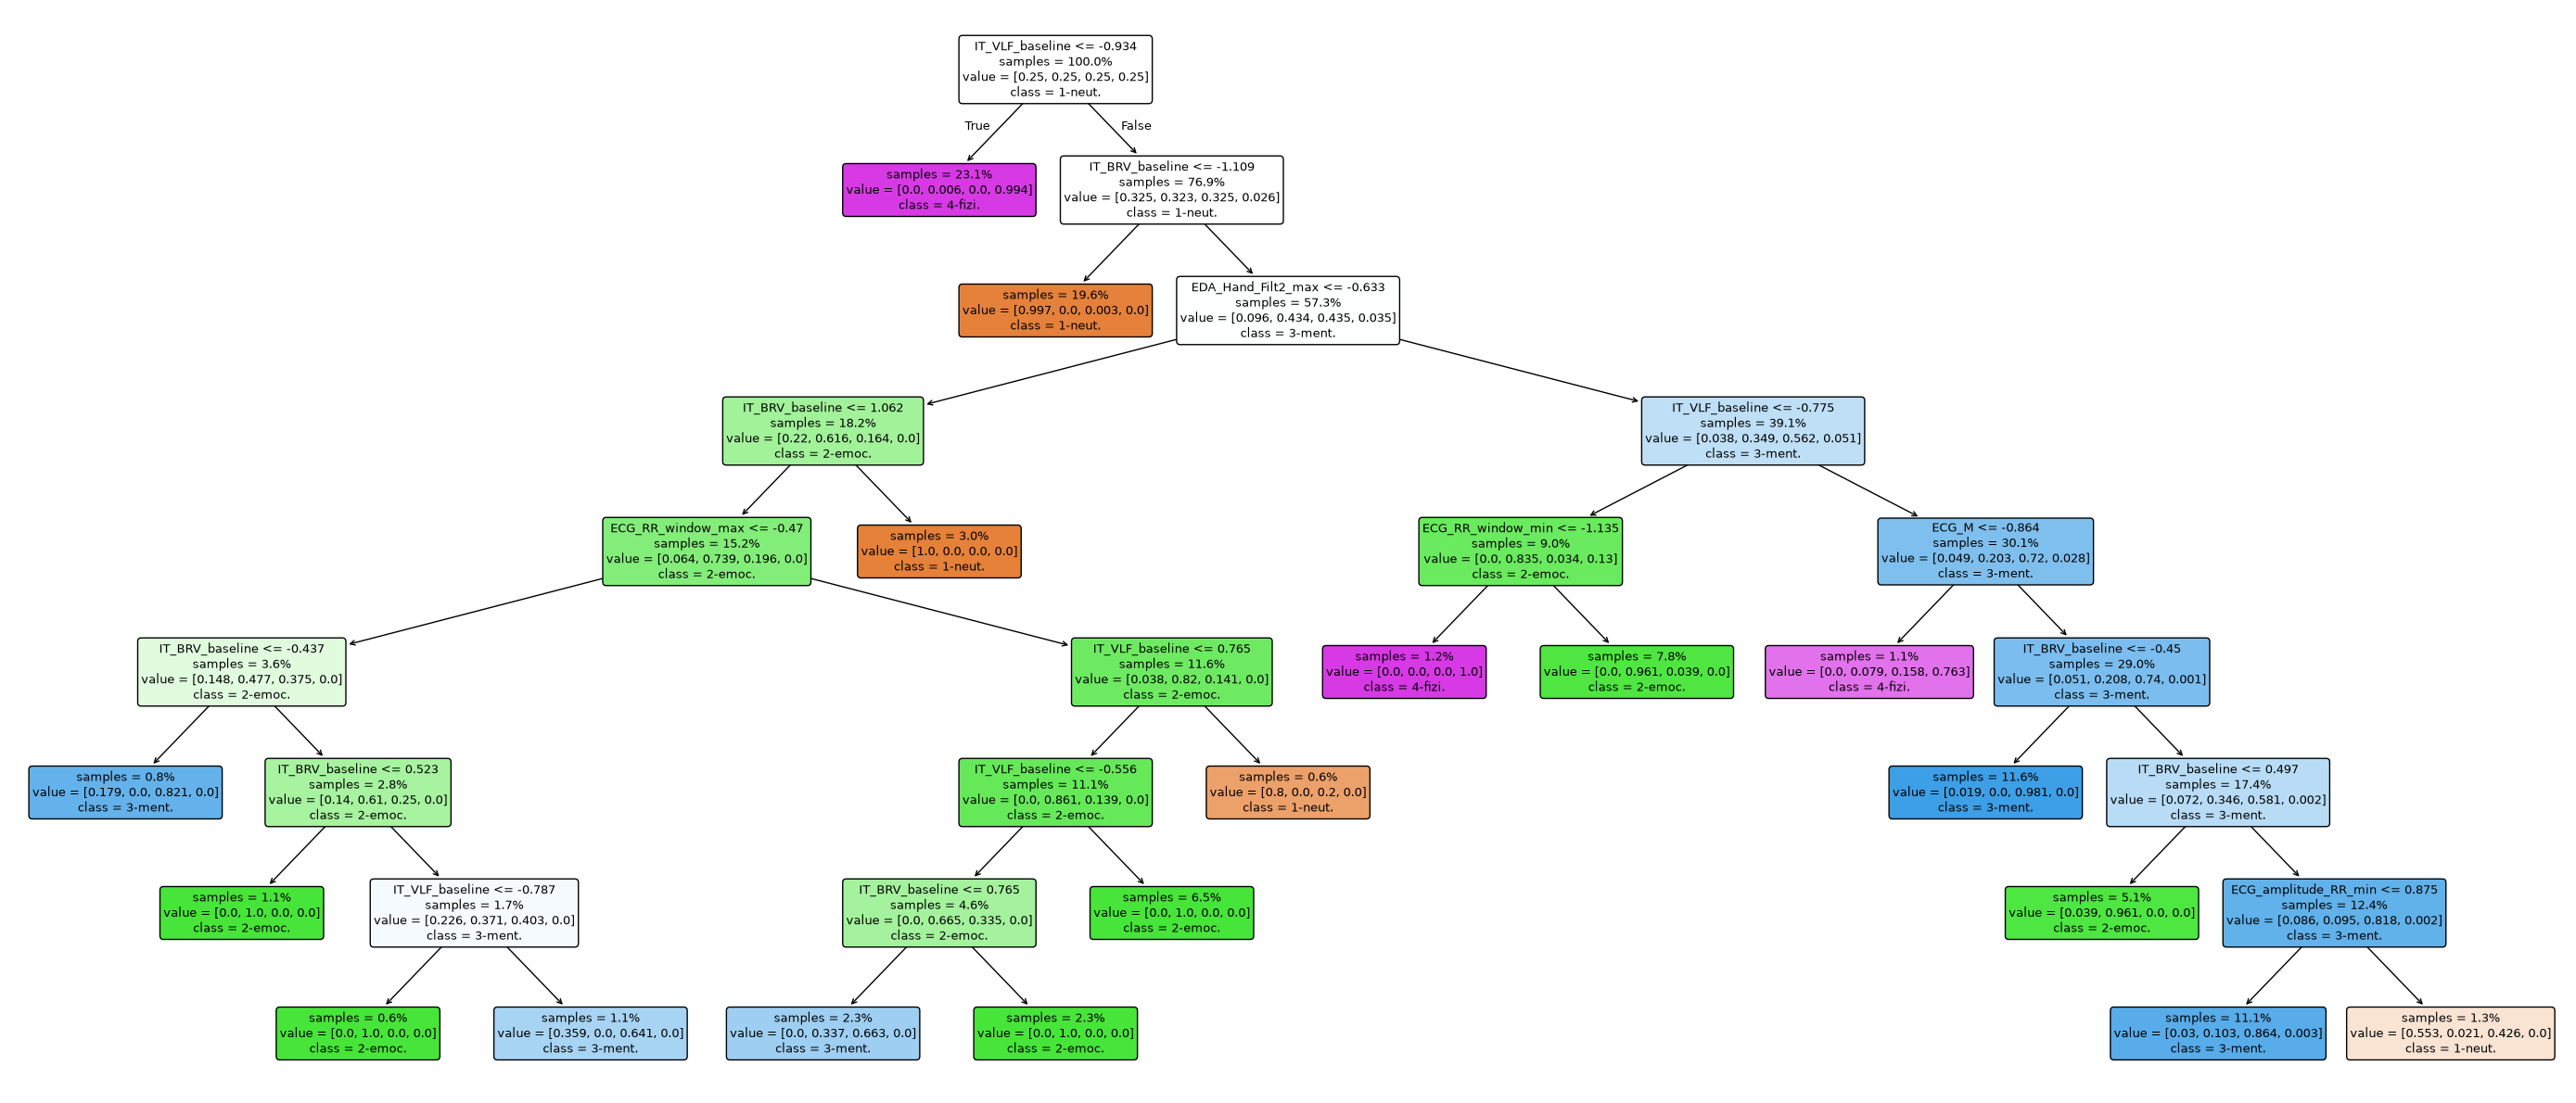

In [10]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

feature_names = list(
    dtc_feature_reduction_gs.best_estimator_
    .named_steps['feature_reduction'].get_feature_names_out()
)
class_names = ["1-neut.", "2-emoc.", "3-ment.", "4-fizi."]

fig, ax = plt.subplots(figsize=(28, 12))
plot_tree(
    tree,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,          # boja = dominantna klasa, zasićenost = čistoća
    rounded=True,
    proportion=True,      # udeli umesto apsolutnih brojeva — čitljivije
    impurity=False,       # Gini vrednosti samo zatrpavaju čvorove
    fontsize=9,
    ax=ax,
)
plt.tight_layout()
# plt.savefig("dtc_interpretable_tree.png", dpi=200, bbox_inches="tight")
plt.show()

In [18]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

mem.clear(warn=False)

dct_pca_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.9, random_state=RANDOM_STATE)),
    ("decision_tree", DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight=None)),
], memory=mem)

param_grid = {
    "decision_tree__criterion": ["gini", "entropy"],
    "decision_tree__max_depth": [2, 3, 4, 5, 6, 8, 10],
    "decision_tree__min_samples_leaf": [1, 5, 10, 20, 40],
    "decision_tree__ccp_alpha": [0.0, 0.001, 0.003, 0.01],
    "decision_tree__max_features": ["sqrt", None, 0.5],
}

cv = GroupKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
dtc_pca_gs = GridSearchCV(dct_pca_pipeline, param_grid=param_grid, cv=cv, n_jobs=-1, verbose=1, scoring="accuracy", refit=True, return_train_score=True)
dtc_pca_gs.fit(X_train_normalized, y_train, groups=groups_train)

print("GridSearch za DecisionTree nad PCA redukovanom skupu atributa: ")
print(" najbolji parametri: ", dtc_pca_gs.best_params_)
print(" broj PCA komponenti: ", dtc_pca_gs.best_estimator_.named_steps["pca"].n_components_)
print(" ukupna objasnjenja varijansa: ", dtc_pca_gs.best_estimator_.named_steps["pca"].explained_variance_ratio_.sum())
print(" najbolja tacnost na unakrsnoj validaciji: ", dtc_pca_gs.best_score_)
print(" tacnost finalnog modela na test skupu: ", dtc_pca_gs.best_estimator_.score(X_test_normalized, y_test))

cm = confusion_matrix(y_test, dtc_pca_gs.predict(X_test_normalized))
classes = ["1-neut.", "2-emoc.", "3-ment.", "4-fizi."]
cm_df = pd.DataFrame(cm, index=classes, columns=classes)
print(" matrica konfuzije:")
print(cm_df)


print(" dodatne statistike klasifikacije: ")
print(classification_report(y_test, dtc_pca_gs.predict(X_test_normalized)))

Fitting 4 folds for each of 840 candidates, totalling 3360 fits
GridSearch za DecisionTree nad PCA redukovanom skupu atributa: 
 najbolji parametri:  {'decision_tree__ccp_alpha': 0.01, 'decision_tree__criterion': 'gini', 'decision_tree__max_depth': 8, 'decision_tree__max_features': 0.5, 'decision_tree__min_samples_leaf': 20}
 broj PCA komponenti:  44
 ukupna objasnjenja varijansa:  0.9004374857767707
 najbolja tacnost na unakrsnoj validaciji:  0.759765625
 tacnost finalnog modela na test skupu:  0.7087053571428571
 matrica konfuzije:
         1-neut.  2-emoc.  3-ment.  4-fizi.
1-neut.      189       16       15        4
2-emoc.        7      176       33        8
3-ment.       22      125       72        5
4-fizi.       10        2       14      198
 dodatne statistike klasifikacije: 
              precision    recall  f1-score   support

           1       0.83      0.84      0.84       224
           2       0.55      0.79      0.65       224
           3       0.54      0.32      0.

In [19]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

mem.clear(warn=False)

dct_lda_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lda", LDA(solver="svd", n_components=3)),
    ("decision_tree", DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight=None)),
], memory=mem)

#nema smisla koristiti max_features, jer imam samo 3 atributa
param_grid = {
    "decision_tree__criterion": ["gini", "entropy"],
    "decision_tree__max_depth": [2, 3, 4, 5, 6, 8, 10],
    "decision_tree__min_samples_leaf": [1, 5, 10, 20, 40],
    "decision_tree__ccp_alpha": [0.0, 0.001, 0.003, 0.01],
}

cv = GroupKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
dtc_lda_gs = GridSearchCV(dct_lda_pipe, param_grid=param_grid, cv=cv, n_jobs=-1, verbose=1, scoring="accuracy", refit=True, return_train_score=True)
dtc_lda_gs.fit(X_train_normalized, y_train, groups=groups_train)

print("GridSearchCV za DecisionTree nad LDA komponentama:")
print(" najbolji parametri: ", dtc_lda_gs.best_params_)
print(" najbolja tacnost na unakrsnoj validaciji: ", dtc_lda_gs.best_score_)
print(" tacnost finalnog modela na test skupu: ", dtc_lda_gs.best_estimator_.score(X_test_normalized, y_test))

cm = confusion_matrix(y_test, dtc_lda_gs.predict(X_test_normalized))
classes = ["1-neut.", "2-emoc.", "3-ment.", "4-fizi."]
cm_df = pd.DataFrame(cm, index=classes, columns=classes)
print(" matrica konfuzije:")
print(cm_df)


print(" dodatne statistike klasifikacije: ")
print(classification_report(y_test, dtc_lda_gs.predict(X_test_normalized)))

Fitting 4 folds for each of 280 candidates, totalling 1120 fits
GridSearchCV za DecisionTree nad LDA komponentama:
 najbolji parametri:  {'decision_tree__ccp_alpha': 0.0, 'decision_tree__criterion': 'gini', 'decision_tree__max_depth': 5, 'decision_tree__min_samples_leaf': 10}
 najbolja tacnost na unakrsnoj validaciji:  0.7603236607142857
 tacnost finalnog modela na test skupu:  0.765625
 matrica konfuzije:
         1-neut.  2-emoc.  3-ment.  4-fizi.
1-neut.      164       11       49        0
2-emoc.        0      117      107        0
3-ment.        0       40      184        0
4-fizi.        0        0        3      221
 dodatne statistike klasifikacije: 
              precision    recall  f1-score   support

           1       1.00      0.73      0.85       224
           2       0.70      0.52      0.60       224
           3       0.54      0.82      0.65       224
           4       1.00      0.99      0.99       224

    accuracy                           0.77       896
   macro

In [14]:
dtc_pipe = Pipeline([
    ("decision_tree", DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight=None))
])

param_grid = {
    "decision_tree__criterion": ["gini", "entropy"],
    "decision_tree__max_depth": [2, 3, 4, 5, 6, 8, 10, 12],
    "decision_tree__min_samples_leaf": [1, 5, 10, 20, 40],
    "decision_tree__ccp_alpha": [0.0, 0.001, 0.003, 0.01],
    "decision_tree__max_features": ["sqrt", None, 0.2, "log2", 0.05],
}

cv = GroupKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
dtc_gs = GridSearchCV(dtc_pipe, param_grid=param_grid, cv=cv, n_jobs=-1, verbose=1, scoring="accuracy", refit=True, return_train_score=True)
dtc_gs.fit(X_train_normalized, y_train, groups=groups_train)

print("GridSearchCV za DecisionTree nad originalnim celim skupom atributa:")
print(" najbolji parametri: ", dtc_gs.best_params_)
print(" najbolja tacnost na unakrsnoj validaciji: ", dtc_gs.best_score_)
print(" tacnost finalnog modela na test skupu: ", dtc_gs.best_estimator_.score(X_test_normalized, y_test))

cm = confusion_matrix(y_test, dtc_gs.predict(X_test_normalized))
classes = ["1-neut.", "2-emoc.", "3-ment.", "4-fizi."]
cm_df = pd.DataFrame(cm, index=classes, columns=classes)
print(" matrica konfuzije:")
print(cm_df)


print(" dodatne statistike klasifikacije: ")
print(classification_report(y_test, dtc_gs.predict(X_test_normalized)))

Fitting 4 folds for each of 1600 candidates, totalling 6400 fits
GridSearchCV za DecisionTree nad originalnim celim skupom atributa:
 najbolji parametri:  {'decision_tree__ccp_alpha': 0.0, 'decision_tree__criterion': 'gini', 'decision_tree__max_depth': 6, 'decision_tree__max_features': None, 'decision_tree__min_samples_leaf': 1}
 najbolja tacnost na unakrsnoj validaciji:  0.8889508928571429
 tacnost finalnog modela na test skupu:  0.9107142857142857
 matrica konfuzije:
         1-neut.  2-emoc.  3-ment.  4-fizi.
1-neut.      191       16       17        0
2-emoc.        0      204       20        0
3-ment.        0       12      212        0
4-fizi.        0       15        0      209
 dodatne statistike klasifikacije: 
              precision    recall  f1-score   support

           1       1.00      0.85      0.92       224
           2       0.83      0.91      0.87       224
           3       0.85      0.95      0.90       224
           4       1.00      0.93      0.97       224

In [15]:
tree = dtc_gs.best_estimator_.named_steps['decision_tree']
print(f"dubina drveta: {tree.get_depth()}, broj listova: {tree.get_n_leaves()}")

i = dtc_gs.best_index_
r = dtc_gs.cv_results_
print(r['mean_test_score'][i], r['std_test_score'][i], r['mean_train_score'][i])
print([r[f'split{k}_test_score'][i] for k in range(4)])

dubina drveta: 6, broj listova: 17
0.8889508928571429 0.037554601246409 0.9840029761904763
[np.float64(0.8459821428571429), np.float64(0.8582589285714286), np.float64(0.9341517857142857), np.float64(0.9174107142857143)]


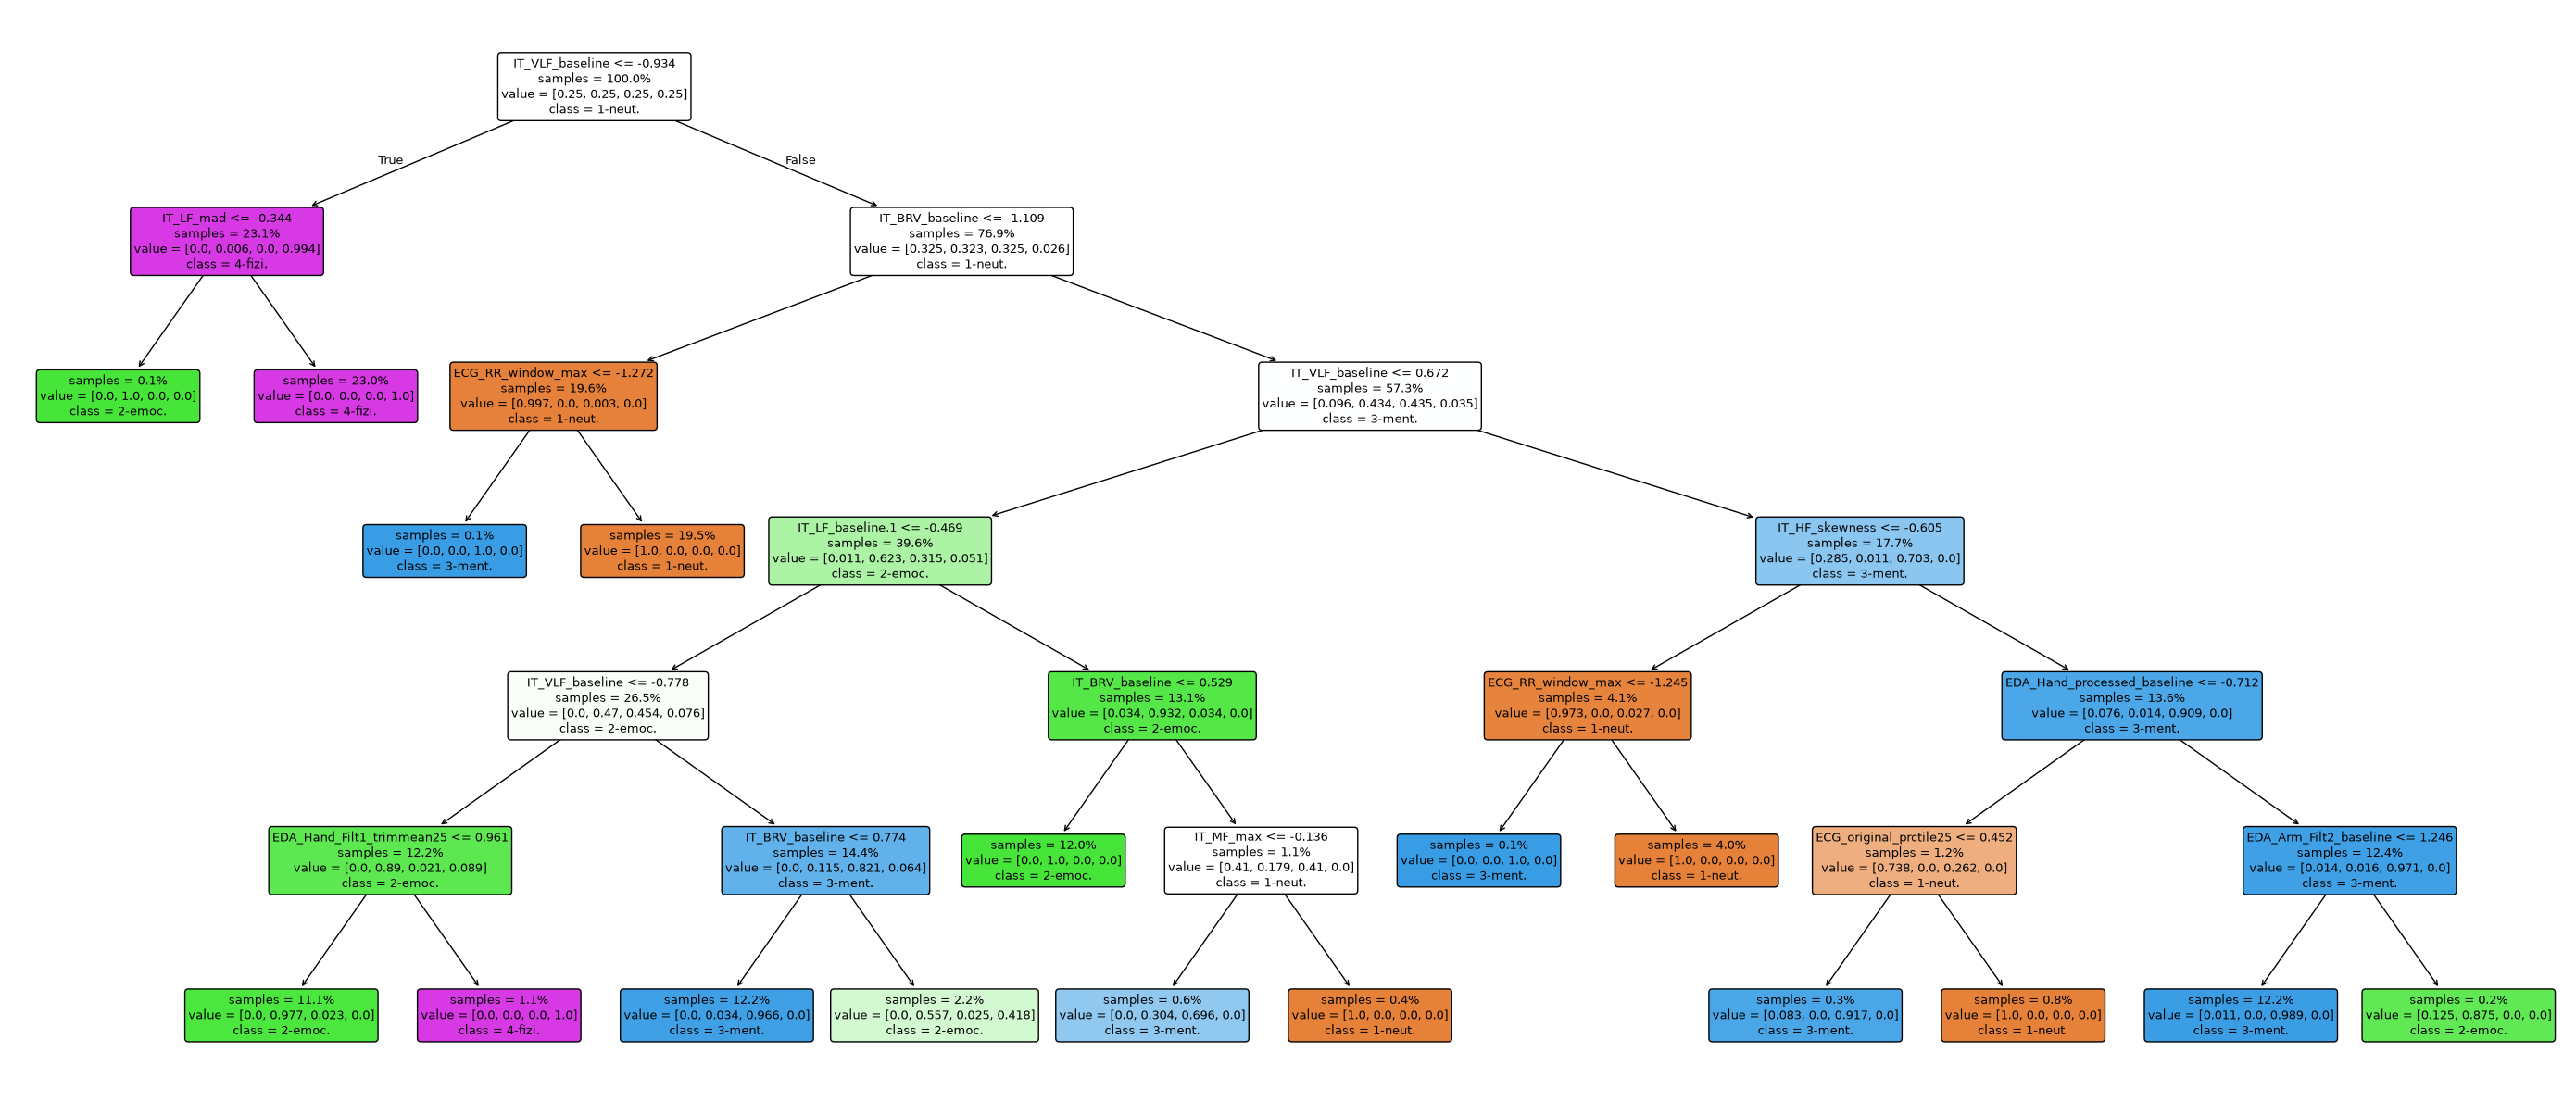

In [17]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

class_names = ["1-neut.", "2-emoc.", "3-ment.", "4-fizi."]

fig, ax = plt.subplots(figsize=(28, 12))
plot_tree(
    tree,
    feature_names=list(X_train_normalized.columns),
    class_names=class_names,
    filled=True,          # boja = dominantna klasa, zasićenost = čistoća
    rounded=True,
    proportion=True,      # udeli umesto apsolutnih brojeva — čitljivije
    impurity=False,       # Gini vrednosti samo zatrpavaju čvorove
    fontsize=9,
    ax=ax,
)
plt.tight_layout()
# plt.savefig("dtc_interpretable_tree.png", dpi=200, bbox_inches="tight")
plt.show()

# Poredjenje stabala odlucivanja nad cetiri skupa atributa

Uslovi su isti kao kod KNN-a: ista podela po subjektu (32 trening / 8 test subjekata), ista normalizacija po subjektu, ista unakrsna validacija `GroupKFold(n_splits=4)` po subjektu i svi koraci redukcije unutar `Pipeline`-a, pa se uce iznova na svakom foldu. `class_weight=None` je opravdan jer su klase savrseno balansirane (po 224 reda svake klase u testu). `StandardScaler` je izostavljen tamo gde se ide direktno u stablo, jer su stabla nezavisna od monotonih transformacija pojedinacnih atributa - skaliranje ne menja nijedan moguci prag.

Mreze parametara se blago razlikuju po skupu, iz sustinskih razloga: kod LDA nema `max_features` (sa svega 3 atributa nema smisla nasumicno birati podskup), a kod punog skupa su dodate manje vrednosti `max_features` (`0.2`, `0.05`, `log2`) i veca dubina (12), jer 533 atributa daju prostor za oboje.

## Zbirni rezultati

| Ulaz u stablo | Broj dimenzija | Najbolji parametri | Tacnost (CV) | Tacnost (test) | Macro F1 (test) |
|---|---|---|---|---|---|
| Interpretabilna redukcija | 15 | gini, max_depth=8, min_samples_leaf=20, ccp_alpha=0.003, max_features=0.5 | **0.9297** | 0.8929 | 0.89 |
| PCA | 44 (90.04% varijanse) | gini, max_depth=8, min_samples_leaf=20, ccp_alpha=0.01, max_features=0.5 | 0.7598 | 0.7087 | 0.70 |
| LDA | 3 | gini, max_depth=5, min_samples_leaf=10, ccp_alpha=0.0 | 0.7603 | 0.7656 | 0.77 |
| Svi atributi | 533 | gini, max_depth=6, min_samples_leaf=1, ccp_alpha=0.0, max_features=None | 0.8890 | **0.9107** | **0.91** |

Zanimljivo je da je `gini` pobedio u sva cetiri slucaja - `entropy` nije izabran nijednom. To je uobicajeno, jer dve mere necistoce daju vrlo slicne podele, pa se razlika medju njima izgubi u sumu unakrsne validacije.

F1 po klasama na test skupu:

| Klasa | Interpretabilna (15) | PCA (44) | LDA (3) | Svi (533) |
|---|---|---|---|---|
| 1 - neutralna | 0.86 | 0.84 | 0.85 | **0.92** |
| 2 - emocionalna | **0.88** | 0.65 | 0.60 | 0.87 |
| 3 - mentalna | 0.87 | 0.40 | 0.65 | **0.90** |
| 4 - fizicka | **0.97** | 0.90 | **0.99** | **0.97** |

Raspodela gresaka na test skupu (896 redova):

| Model | Ukupno gresaka | emoc. <-> ment. | Udeo tog para | Tacnost na paru emoc.+ment. | Tacnost na neut.+fizickoj | Greske koje ukljucuju fizicku |
|---|---|---|---|---|---|---|
| Interpretabilna (15) | 96 | **23** | **24.0%** | 0.900 | 0.886 | 15 |
| PCA (44) | 261 | 158 | 60.5% | 0.554 | 0.864 | 43 |
| LDA (3) | 210 | 147 | 70.0% | 0.672 | 0.859 | 3 |
| Svi (533) | **80** | 32 | 40.0% | **0.929** | **0.893** | 15 |

Detaljnija analiza dva najbolja modela (iz celija sa karakteristikama drveta):

| | Interpretabilna (15) | Svi (533) |
|---|---|---|
| Dubina drveta | 8 | 6 |
| Broj listova | 18 | 17 |
| Prosecna tacnost na trening delu foldova | 0.9556 | 0.9840 |
| Prosecna tacnost na validacionom delu foldova | 0.9297 | 0.8890 |
| Razlika trening - validacija | **0.0259** | 0.0951 |
| Standardna devijacija po foldovima | **0.0210** | 0.0376 |
| Tacnost po foldovima | 0.9420 / 0.8951 / 0.9319 / 0.9498 | 0.8460 / 0.8583 / 0.9342 / 0.9174 |
| Raspon izmedju najboljeg i najloseg folda | **0.055** | 0.088 |

## Sta rezultati govore

### 1. Kod stabla se poredak skupova atributa potpuno obrce u odnosu na KNN

Ovo je najupadljiviji rezultat. Poredjenje istih skupova atributa kod dva modela:

| Skup atributa | KNN (CV) | KNN (test) | Stablo (CV) | Stablo (test) | Razlika na testu |
|---|---|---|---|---|---|
| Interpretabilna redukcija (15) | 0.8209 | 0.8080 | 0.9297 | 0.8929 | **+0.085** |
| PCA (44) | 0.7653 | 0.7679 | 0.7598 | 0.7087 | -0.059 |
| LDA (3) | 0.7606 | 0.8025 | 0.7603 | 0.7656 | -0.037 |
| Svi atributi (533) | 0.7709 | 0.7645 | 0.8890 | 0.9107 | **+0.146** |

Pravilo je jasno: **nad originalnim atributima stablo je znatno bolje od KNN-a, a nad projekcijama je losije.** Uzrok je u tome sto ta dva modela traze suprotne stvari u podacima.

KNN gleda rastojanje, koje sabira doprinose svih atributa podjednako, pa ga 518 nebitnih atributa uguse - zato mu je pun skup bio najlosiji ulaz, a redukcija je pomogla. Stablo, nasuprot tome, u svakom cvoru bira jedan atribut i jedan prag; nebitni atributi jednostavno nikada ne budu izabrani i ne kostaju nista. Zato veci broj atributa stablu daje samo vise prilika da nadje dobar prag, pa je puni skup od 533 atributa njegov najbolji ulaz, dok mu redukcija na 15 atributa oduzima kandidate za podelu.

Isto objasnjenje vazi i u drugom smeru: PCA i LDA komponente su guste linearne kombinacije svih 533 atributa, u kojima vise ne postoji "prag na jednom merenju". Podela po jednoj komponenti u originalnom prostoru odgovara kosoj hiperravni, a to je bas ono sto stablo ne ume da gradi - moze samo da je aproksimira stepenicasto, uz mnogo cvorova. Zato projekcije, koje su KNN-u pomagale da sazme prostor, stablu odnose bas onu strukturu na kojoj pociva.

### 2. PCA je najlosiji izbor za stablo

Sa 0.7087 na testu, PCA je ubedljivo najgori od svih osam modela (i KNN i stablo) do sada. Najgori deo je odziv mentalne klase od svega **0.32**: cak 125 od 224 mentalna reda zavrsi kao emocionalna. To je ocekivano posle prethodne tacke - PCA je istovremeno i nenadgledana (komponente ne znaju za klasu) i gusta (nijedan mali skup atributa "nije" komponenta, sto je pokazano u `feature_reduction.ipynb`: 10 najvecih koeficijenata nosi svega 3.5-7.7% mase komponente). Stablo nad takvim ulazom nema ni informativan pravac ni ostar prag.

### 3. LDA: stablo je gore i od KNN-a i od same LDA

Nad LDA komponentama stablo daje 0.7656, dok je KNN nad istim ulazom davao 0.8025, a sama LDA kao klasifikator 0.796. Dakle stablo je ovde najlosiji izbor od tri. Razlog je isti kao gore, samo jos izrazeniji: LDA je vec izracunala optimalne *linearne* granice, pa je najbolje sto stablo moze da uradi to da tu istu granicu aproksimira stepenicasto, a svaka stepenica je gubitak. Uz to su LDA komponente nadgledane, pa je ulaz vec potrosio sve sto se linearno moglo izvuci - stablu ne ostaje nikakva dodatna nelinearnost koju bi iskoristilo.

Vredi primetiti da je LDA jedini slucaj gde `ccp_alpha=0.0` i mala dubina (5) prolaze bez potkresivanja: u tri dimenzije nema mnogo prostora za preprilagodjavanje.

### 4. Zid izmedju emocionalne i mentalne aktivnosti nije svojstvo podataka, nego linearnih projekcija

Kod KNN-a je zakljucak bio da je par emocionalna-mentalna granica koju nijedan pristup ne probija (oko 0.70 tacnosti na tom paru). **Stabla pokazuju da to nije tacno**: na istom paru od 448 test redova stablo nad punim skupom postize **0.929**, a nad interpretabilnih 15 atributa **0.900**, naspram najboljih 0.725 kod KNN-a. Udeo tog para u ukupnim greskama pada sa 60.5% na 24.0% (interpretabilni skup), a odziv mentalne klase raste sa 0.62 na 0.93.

Kljucno je da se stari obrazac zadrzao tacno tamo gde se i ocekuje - kod PCA (60.5% gresaka na tom paru) i LDA (70.0%). Nalaz iz `feature_reduction.ipynb`, da se emocionalna i mentalna ne razdvajaju, zato treba precizirati: one se ne razdvajaju **u pravcima najvece varijanse niti bilo kojom linearnom granicom**, ali se dobro razdvajaju uslovnim pragovima nad pojedinacnim merenjima.

Verovatno objasnjenje, koje se moze proveriti direktno na prikazu drveta iznad, jeste to sto stablo ume da gradi *uslovna* pravila oblika "ako je atribut A iznad praga, onda gledaj atribut B, inace atribut C". Bas takvu strukturu ima `IT_BRV_baseline`, atribut sa najvecom uzajamnom informacijom: analiza raspodela je pokazala da 6 od 32 trening subjekta imaju **obrnut poredak klasa** po tom atributu, pa ista z-vrednost kod razlicitih ljudi znaci razlicitu klasu. Linearan ili monoton model tu ne moze nista (i zato globalna eta-kvadrat vrednost tog atributa ostaje 0.33 uprkos uzajamnoj informaciji od 1.134), ali stablo moze prvo da razdvoji te dve grupe subjekata, a zatim da u svakoj grani primeni suprotan prag.

### 5. Stabla su mala i citljiva, pa je i puni skup atributa ostao interpretabilan

Najbolje stablo nad svih 533 atributa ima dubinu 6 i samo **17 listova** - dakle koristi najvise 17 pravila i, u najgorem slucaju, 6 poredjenja po redu. Stablo nad 15 atributa je cak i nesto vece (dubina 8, 18 listova), iako bira iz 35 puta manjeg skupa.

To je vredan zakljucak: dodatni atributi nisu doveli do slozenijeg modela, nego do **jednostavnijeg i tacnijeg** - sa boljim kandidatima za podelu potrebno je manje podela. Zbog toga argument interpretabilnosti, koji je bio glavni razlog za nadgledanu redukciju umesto PCA, ovde delimicno gubi na snazi: i stablo nad punim skupom moze da se procita kao skup pravila nad konkretnim merenjima sa senzora, jer i ono na kraju koristi samo nekoliko atributa. Prednost redukcije ostaje u tome sto se tih 15 atributa zna unapred i sto ne zavise od toga koje ce atribute stablo izabrati.

### 6. Koji model zapravo treba izabrati: stablo nad 15 atributa

Puni skup ima bolju tacnost na testu (0.9107 naspram 0.8929), ali interpretabilni skup ima bolju unakrsnu validaciju (0.9297 naspram 0.8890), a to je pouzdaniji kriterijum, jer je usrednjen preko sva 32 trening subjekta, dok test skup ima samo 8 nezavisnih subjekata. Detaljne statistike idu u istom smeru:

- **Preprilagodjavanje**: stablo nad punim skupom ima razliku trening-validacija od 0.0951, skoro cetiri puta vecu od 0.0259 kod interpretabilnog skupa. To je i ocekivano s obzirom na izabrane parametre - `min_samples_leaf=1`, `ccp_alpha=0.0` i `max_features=None` znace da nema nikakvog potkresivanja i da se u svakom cvoru gleda svih 533 atributa, pa je dubina 6 ispala jedina kocnica. Interpretabilni model je izabrao stvarnu regularizaciju: `min_samples_leaf=20`, `ccp_alpha=0.003` i `max_features=0.5`.
- **Stabilnost**: standardna devijacija po foldovima je 0.0210 naspram 0.0376, a raspon izmedju najboljeg i najloseg folda 0.055 naspram 0.088. Stablo nad punim skupom pada na 0.846 u najlosijem foldu, sto znaci da mu rezultat osetno zavisi od toga koji su subjekti u validaciji.
- Razlika u tacnosti na testu (0.018) je manja od raspona po foldovima kod oba modela, pa je ne treba tumaciti kao stvarnu prednost.

Treba imati u vidu i **efekat pobednika** pri ovako velikim mrezama: kod punog skupa je isprobano 1600 kombinacija, kod ostalih 840 odnosno 280. Sto je vise kandidata, to je maksimum CV ocene vise precenjen, jer se bira najbolji od mnogo sumovitih rezultata. Kod punog skupa je, doduse, test ocena ispala *veca* od CV ocene, pa taj efekat ovde ocigledno nije presudan, ali je jos jedan razlog da se dva modela smatraju izjednacenim, umesto da se puni skup proglasi boljim.

### 7. Nova vrsta greske koju stablo pravi

KNN nad 15 atributa je imao **nula** gresaka bilo kakve veze sa fizickom aktivnoscu - savrsenih 224/224. Stabla su tu blago losija: 15 gresaka kod oba najbolja modela, i to gotovo iskljucivo u smeru koji KNN nije pravio (8 fizickih redova proglasenih emocionalnim kod interpretabilnog modela, 15 kod punog). Uzrok je priroda ostrih pragova: stablo pravi granicu na jednoj vrednosti, pa nekoliko redova neposredno uz prag padne na pogresnu stranu, dok KNN sa velikim susedstvom (k=91) tu istu odluku donosi glasanjem i granicne slucajeve "izgladi".

To je razmena koja se isplati: stablo gubi 15 redova na fizickoj klasi, a dobija 81 red na paru emocionalna-mentalna.

## Zakljucak

**Stablo odlucivanja je znatno bolji model za ovaj problem od KNN-a**, ali samo ako radi nad originalnim atributima: 0.8929 (15 atributa) i 0.9107 (svih 533) naspram najboljih 0.8080 kod KNN-a. Nad projekcijama (PCA 0.7087, LDA 0.7656) stablo je losije od KNN-a, jer PCA i LDA unistavaju bas onu strukturu - prag na pojedinacnom merenju - na kojoj stablo pociva.

Kao finalni model biramo **stablo nad interpretabilnom redukcijom na 15 atributa** (gini, max_depth=8, min_samples_leaf=20, ccp_alpha=0.003, max_features=0.5): ima najbolju unakrsnu validaciju (0.9297), najmanje preprilagodjavanje (razlika trening-validacija 0.0259), najstabilnije ponasanje po foldovima (std 0.0210) i sa 18 listova nad 15 imenovanih merenja ostaje potpuno objasnjivo. Stablo nad punim skupom je po tacnosti izjednaceno, ali je nestabilnije i bez ijednog stvarnog mehanizma regularizacije.

Najvazniji sadrzinski nalaz je to da **par emocionalna-mentalna nije nerazdvojiv**, kako je izgledalo iz projekcione analize i iz KNN rezultata. Tacnost na tom paru raste sa 0.70 (KNN) na 0.90-0.93 (stablo nad originalnim atributima), dok kod PCA i LDA ostaje na starih 0.55-0.67. Zakljucak iz `feature_reduction.ipynb` zato treba citati kao tvrdnju o **linearnim projekcijama**, a ne o samim podacima: te dve aktivnosti se ne razlikuju po pravcima najvece varijanse niti po bilo kojoj ravnoj granici, ali se razlikuju po uslovnim pragovima nad pojedinacnim fizioloskim merenjima - sto je i ocekivano kod atributa poput `IT_BRV_baseline`, kod kojeg jedna podgrupa ispitanika ima obrnut poredak klasa.

## Dodatno

U reviziji objasnjenja, moze da se vise sagleda deo 6 (biranje najboljeg modela) i mozda detaljnija analiza i bolji opis i poredjenje plotova dva stabla i ucesca atributa u oba slucajeva izmedju modela nad celim skupom atributa i redukovanim nasom intepretabilnom redukcijom.


In [21]:
from sklearn.preprocessing import PowerTransformer
from sklearn.naive_bayes import GaussianNB

mem.clear(warn=False)

# PowerTransformer(method="yeo-johnson") je nenadgledana transformacija atributa tako da popravlja iskosenost u raspodelama
# pa da atributi (njihove objedinjenje raspodele)budu sto blizi normalnoj raspodeli, sto je i preduslov naivnog bajesa, da raspodele atirbuta u okviru klasa budu
# normalne i medjusobno nezavisne
# ovde scaler posmatramo kao hiperparametar, gde koristimo PowerTransformer, i preskacemo ga koriscenjem kljucne reci 'passthrough'
# PowerTransformer(method="yeo-johnson") moze i da odmogne u slucajevima kada je objedinjena raspodela atributa visemodalna
nb_feature_reduction_pipe = Pipeline([
    ("feature_reduction", InterpretableFeatureReducer()),
    ("prep", PowerTransformer(method="yeo-johnson")),
    ("nb", GaussianNB()),
], memory=mem)

param_grid = {
    "prep": [PowerTransformer(method="yeo-johnson"), "passthrough"],
    "nb__var_smoothing": np.logspace(-5, 1, 30)
}

cv = GroupKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
nb_feature_reduction_gs = GridSearchCV(nb_feature_reduction_pipe, param_grid=param_grid, cv=cv, n_jobs=-1, verbose=1, scoring="accuracy", refit=True, return_train_score=True)
nb_feature_reduction_gs.fit(X_train_normalized, y_train, groups=groups_train)

print("GridSearch za Naivnog Bajesa nad intepretabilnom, redukovanom skupu atributa: ")
print(" najbolji parametri: ", nb_feature_reduction_gs.best_params_)
print(" atributi izabrani u finalnom modelu: ", list(nb_feature_reduction_gs.best_estimator_.named_steps["feature_reduction"].get_feature_names_out()))
print(" najbolja tacnost na unakrsnoj validaciji: ", nb_feature_reduction_gs.best_score_)
print(" tacnost finalnog modela na test skupu: ", nb_feature_reduction_gs.best_estimator_.score(X_test_normalized, y_test))

cm = confusion_matrix(y_test, nb_feature_reduction_gs.predict(X_test_normalized))
classes = ["1-neut.", "2-emoc.", "3-ment.", "4-fizi."]
cm_df = pd.DataFrame(cm, index=classes, columns=classes)
print(" matrica konfuzije:")
print(cm_df)


print(" dodatne statistike klasifikacije: ")
print(classification_report(y_test, nb_feature_reduction_gs.predict(X_test_normalized)))

Fitting 4 folds for each of 60 candidates, totalling 240 fits


/home/boce/Desktop/ml_activity_classification/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/boce/Desktop/ml_activity_classification/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/boce/Desktop/ml_activity_classification/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  w

GridSearch za Naivnog Bajesa nad intepretabilnom, redukovanom skupu atributa: 
 najbolji parametri:  {'nb__var_smoothing': np.float64(0.9236708571873865), 'prep': PowerTransformer()}
 atributi izabrani u finalnom modelu:  ['IT_BRV_baseline', 'IT_VLF_baseline', 'ECG_amplitude_RR_min', 'IT_Original_max', 'IT_RF_max', 'EDA_Hand_Filt2_max', 'EDA_Arm_Filt2_min', 'ECG_amplitude_RR_max', 'EDA_Hand_processed_min', 'EDA_Arm_processed_max', 'EDA_Arm_processed_min', 'ECG_RR_window_min', 'ECG_RR_window_max', 'IT_BR_mean', 'ECG_M']
 najbolja tacnost na unakrsnoj validaciji:  0.7087053571428572
 tacnost finalnog modela na test skupu:  0.6741071428571429
 matrica konfuzije:
         1-neut.  2-emoc.  3-ment.  4-fizi.
1-neut.      187        6       31        0
2-emoc.       37      139       48        0
3-ment.       72       96       56        0
4-fizi.        0        0        2      222
 dodatne statistike klasifikacije: 
              precision    recall  f1-score   support

           1       0.

In [22]:
i = nb_feature_reduction_gs.best_index_
r = nb_feature_reduction_gs.cv_results_
print(r['mean_test_score'][i], r['std_test_score'][i], r['mean_train_score'][i])
print([r[f'split{k}_test_score'][i] for k in range(4)])

0.7087053571428572 0.03497419557141159 0.7514880952380952
[np.float64(0.6863839285714286), np.float64(0.6640625), np.float64(0.7332589285714286), np.float64(0.7511160714285714)]


In [29]:
mem.clear(warn=False)

nb_pca_pipe = Pipeline([
    ("prep", PowerTransformer(method="yeo-johnson")),
    ("pca", PCA(n_components=0.9, whiten=True, random_state=RANDOM_STATE)),
    ("nb", GaussianNB()),
], memory=mem)

param_grid = {
    "prep": [PowerTransformer(method="yeo-johnson"), StandardScaler()],
    "nb__var_smoothing": np.logspace(-5, 1, 30)
}

cv = GroupKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
nb_pca_gs = GridSearchCV(nb_pca_pipe, param_grid=param_grid, cv=cv, n_jobs=-1, verbose=1, scoring="accuracy", refit=True, return_train_score=True)
nb_pca_gs.fit(X_train_normalized, y_train, groups=groups_train)

print("GridSearch za Naivnog Bajesa nad PCA komponentama: ")
print(" najbolji parametri: ", nb_pca_gs.best_params_)
print(" broj PCA komponenti: ", nb_pca_gs.best_estimator_.named_steps["pca"].n_components_)
print(" ukupna objasnjenja varijansa: ", nb_pca_gs.best_estimator_.named_steps["pca"].explained_variance_ratio_.sum())
print(" najbolja tacnost na unakrsnoj validaciji: ", nb_pca_gs.best_score_)
print(" tacnost finalnog modela na test skupu: ", nb_pca_gs.best_estimator_.score(X_test_normalized, y_test))

cm = confusion_matrix(y_test, nb_pca_gs.predict(X_test_normalized))
classes = ["1-neut.", "2-emoc.", "3-ment.", "4-fizi."]
cm_df = pd.DataFrame(cm, index=classes, columns=classes)
print(" matrica konfuzije:")
print(cm_df)


print(" dodatne statistike klasifikacije: ")
print(classification_report(y_test, nb_pca_gs.predict(X_test_normalized)))

Fitting 4 folds for each of 60 candidates, totalling 240 fits
GridSearch za Naivnog Bajesa nad PCA komponentama: 
 najbolji parametri:  {'nb__var_smoothing': np.float64(0.0007278953843983146), 'prep': StandardScaler()}
 broj PCA komponenti:  44
 ukupna objasnjenja varijansa:  0.9004374857767707
 najbolja tacnost na unakrsnoj validaciji:  0.7873883928571429
 tacnost finalnog modela na test skupu:  0.7779017857142857
 matrica konfuzije:
         1-neut.  2-emoc.  3-ment.  4-fizi.
1-neut.      171       15       27       11
2-emoc.        1      166       48        9
3-ment.        0       80      139        5
4-fizi.        0        0        3      221
 dodatne statistike klasifikacije: 
              precision    recall  f1-score   support

           1       0.99      0.76      0.86       224
           2       0.64      0.74      0.68       224
           3       0.64      0.62      0.63       224
           4       0.90      0.99      0.94       224

    accuracy                     

In [30]:
i = nb_pca_gs.best_index_
r = nb_pca_gs.cv_results_
print(r['mean_test_score'][i], r['std_test_score'][i], r['mean_train_score'][i])
print([r[f'split{k}_test_score'][i] for k in range(4)])

0.7873883928571429 0.028558128531080328 0.8161272321428571
[np.float64(0.7991071428571429), np.float64(0.7544642857142857), np.float64(0.828125), np.float64(0.7678571428571429)]


In [25]:
mem.clear(warn=False)

nb_lda_pipe = Pipeline([
    ("prep", PowerTransformer(method="yeo-johnson")),
    ("lda", LDA(solver="svd", n_components=3)),
    ("nb", GaussianNB()),
], memory=mem)

param_grid = {
    "prep": [PowerTransformer(method="yeo-johnson"), StandardScaler()],
    "nb__var_smoothing": np.logspace(-5, 1, 30)
}

cv = GroupKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
nb_lda_gs = GridSearchCV(nb_lda_pipe, param_grid=param_grid, cv=cv, n_jobs=-1, verbose=1, scoring="accuracy", refit=True, return_train_score=True)
nb_lda_gs.fit(X_train_normalized, y_train, groups=groups_train)

print("GridSearch za Naivnog Bajesa nad LDA komponentama: ")
print(" najbolji parametri: ", nb_lda_gs.best_params_)
print(" najbolja tacnost na unakrsnoj validaciji: ", nb_lda_gs.best_score_)
print(" tacnost finalnog modela na test skupu: ", nb_lda_gs.best_estimator_.score(X_test_normalized, y_test))

cm = confusion_matrix(y_test, nb_lda_gs.predict(X_test_normalized))
classes = ["1-neut.", "2-emoc.", "3-ment.", "4-fizi."]
cm_df = pd.DataFrame(cm, index=classes, columns=classes)
print(" matrica konfuzije:")
print(cm_df)


print(" dodatne statistike klasifikacije: ")
print(classification_report(y_test, nb_lda_gs.predict(X_test_normalized)))

Fitting 4 folds for each of 60 candidates, totalling 240 fits
GridSearch za Naivnog Bajesa nad LDA komponentama: 
 najbolji parametri:  {'nb__var_smoothing': np.float64(0.08531678524172806), 'prep': StandardScaler()}
 najbolja tacnost na unakrsnoj validaciji:  0.7583705357142857
 tacnost finalnog modela na test skupu:  0.8013392857142857
 matrica konfuzije:
         1-neut.  2-emoc.  3-ment.  4-fizi.
1-neut.      193       20       11        0
2-emoc.        0      146       78        0
3-ment.        2       60      162        0
4-fizi.        0        0        7      217
 dodatne statistike klasifikacije: 
              precision    recall  f1-score   support

           1       0.99      0.86      0.92       224
           2       0.65      0.65      0.65       224
           3       0.63      0.72      0.67       224
           4       1.00      0.97      0.98       224

    accuracy                           0.80       896
   macro avg       0.82      0.80      0.81       896
weig

In [26]:
i = nb_lda_gs.best_index_
r = nb_lda_gs.cv_results_
print(r['mean_test_score'][i], r['std_test_score'][i], r['mean_train_score'][i])
print([r[f'split{k}_test_score'][i] for k in range(4)])

0.7583705357142857 0.0476426565591328 0.951357886904762
[np.float64(0.7321428571428571), np.float64(0.7232142857142857), np.float64(0.8404017857142857), np.float64(0.7377232142857143)]


In [27]:
mem.clear(warn=False)

nb_pipe = Pipeline([
    ("prep", PowerTransformer(method="yeo-johnson")),
    ("nb", GaussianNB()),
], memory=mem)

param_grid = {
    "prep": [PowerTransformer(method="yeo-johnson"), "passthrough"],
    "nb__var_smoothing": np.logspace(-5, 1, 30)
}

cv = GroupKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
nb_gs = GridSearchCV(nb_pipe, param_grid=param_grid, cv=cv, n_jobs=-1, verbose=1, scoring="accuracy", refit=True, return_train_score=True)
nb_gs.fit(X_train_normalized, y_train, groups=groups_train)

print("GridSearch za Naivnog Bajesa nad originalnim celim skupom atributa: ")
print(" najbolji parametri: ", nb_gs.best_params_)
print(" najbolja tacnost na unakrsnoj validaciji: ", nb_gs.best_score_)
print(" tacnost finalnog modela na test skupu: ", nb_gs.best_estimator_.score(X_test_normalized, y_test))

cm = confusion_matrix(y_test, nb_gs.predict(X_test_normalized))
classes = ["1-neut.", "2-emoc.", "3-ment.", "4-fizi."]
cm_df = pd.DataFrame(cm, index=classes, columns=classes)
print(" matrica konfuzije:")
print(cm_df)


print(" dodatne statistike klasifikacije: ")
print(classification_report(y_test, nb_gs.predict(X_test_normalized)))

Fitting 4 folds for each of 60 candidates, totalling 240 fits
GridSearch za Naivnog Bajesa nad originalnim celim skupom atributa: 
 najbolji parametri:  {'nb__var_smoothing': np.float64(9.999999999999999e-06), 'prep': PowerTransformer()}
 najbolja tacnost na unakrsnoj validaciji:  0.7728794642857143
 tacnost finalnog modela na test skupu:  0.7845982142857143
 matrica konfuzije:
         1-neut.  2-emoc.  3-ment.  4-fizi.
1-neut.      184       17       23        0
2-emoc.        0      126       98        0
3-ment.        0       53      171        0
4-fizi.        0        0        2      222
 dodatne statistike klasifikacije: 
              precision    recall  f1-score   support

           1       1.00      0.82      0.90       224
           2       0.64      0.56      0.60       224
           3       0.58      0.76      0.66       224
           4       1.00      0.99      1.00       224

    accuracy                           0.78       896
   macro avg       0.81      0.78    

In [28]:
i = nb_gs.best_index_
r = nb_gs.cv_results_
print(r['mean_test_score'][i], r['std_test_score'][i], r['mean_train_score'][i])
print([r[f'split{k}_test_score'][i] for k in range(4)])

0.7728794642857143 0.04239235387345692 0.8390066964285715
[np.float64(0.703125), np.float64(0.7745535714285714), np.float64(0.8058035714285714), np.float64(0.8080357142857143)]


## Poredjenje naivnog Bajesa nad cetiri skupa atributa

Uslovi su isti kao kod prethodna dva modela: ista podela po subjektu, ista normalizacija po subjektu, `GroupKFold(n_splits=4)` po subjektu i svi koraci redukcije unutar `Pipeline`-a. Model je `GaussianNB`, a mreza pretrage ima 60 kombinacija (240 fitova) po skupu atributa:

- `nb__var_smoothing` iz `np.logspace(-5, 1, 30)` - koliko se najvece varijanse dodaje svim varijansama, dakle koliko se "razmazuju" naucene normalne raspodele;
- korak `prep` se tretira kao **hiperparametar**: `PowerTransformer(method="yeo-johnson")` naspram `passthrough` (kod interpretabilnog i punog skupa), odnosno naspram `StandardScaler()` (kod PCA i LDA). Yeo-Johnson ispravlja iskosenost raspodela, sto je direktno u sluzbi pretpostavke naivnog Bajesa da su raspodele atributa unutar klase normalne.

Dve razlike medju celijama koje treba imati na umu pri citanju rezultata: kod PCA i LDA `prep` stoji **ispred** projekcije, pa je to izbor pripreme za projekciju, a ne za sam naivni Bajes; i PCA je u ovoj celiji fiksirana na `whiten=True`, sto nije poredjeno sa `whiten=False` kao u KNN celiji.

## Zbirni rezultati

| Ulaz u naivni Bajes | Broj dimenzija | Najbolji parametri | Tacnost (CV) | Tacnost (test) | Macro F1 (test) |
|---|---|---|---|---|---|
| Interpretabilna redukcija | 15 | var_smoothing=0.9237, PowerTransformer | 0.7087 | 0.6741 | 0.66 |
| PCA | 44 (90.04% varijanse, whiten) | var_smoothing=0.000728, StandardScaler | **0.7874** | 0.7779 | 0.78 |
| LDA | 3 | var_smoothing=0.0853, StandardScaler | 0.7584 | **0.8013** | **0.81** |
| Svi atributi | 533 | var_smoothing=1e-05, PowerTransformer | 0.7729 | 0.7846 | 0.79 |

F1 po klasama na test skupu:

| Klasa | Interpretabilna (15) | PCA (44) | LDA (3) | Svi (533) |
|---|---|---|---|---|
| 1 - neutralna | 0.72 | 0.86 | **0.92** | 0.90 |
| 2 - emocionalna | 0.60 | **0.68** | 0.65 | 0.60 |
| 3 - mentalna | 0.31 | 0.63 | **0.67** | 0.66 |
| 4 - fizicka | **1.00** | 0.94 | 0.98 | **1.00** |

Raspodela gresaka na test skupu (896 redova):

| Model | Ukupno gresaka | emoc. <-> ment. | Udeo tog para | Tacnost na paru emoc.+ment. | Tacnost na neut.+fizickoj | Greske koje ukljucuju fizicku |
|---|---|---|---|---|---|---|
| Interpretabilna (15) | 292 | 144 | 49.3% | 0.435 | 0.913 | **2** |
| PCA (44) | 199 | 128 | 64.3% | 0.681 | 0.875 | 28 |
| LDA (3) | **178** | 138 | 77.5% | **0.688** | **0.915** | 7 |
| Svi (533) | 193 | 151 | 78.2% | 0.663 | 0.906 | **2** |

Stabilnost, iz celija sa detaljnom analizom:

| | Interpretabilna (15) | PCA (44) | LDA (3) | Svi (533) |
|---|---|---|---|---|
| Prosecna tacnost na trening delu foldova | 0.7515 | 0.8161 | 0.9514 | 0.8390 |
| Prosecna tacnost na validacionom delu | 0.7087 | **0.7874** | 0.7584 | 0.7729 |
| Razlika trening - validacija | 0.0428 | **0.0287** | 0.1930 | 0.0661 |
| Standardna devijacija po foldovima | 0.0350 | **0.0286** | 0.0476 | 0.0424 |
| Tacnost po foldovima | 0.686 / 0.664 / 0.733 / 0.751 | 0.799 / 0.754 / 0.828 / 0.768 | 0.732 / 0.723 / 0.840 / 0.738 | 0.703 / 0.775 / 0.806 / 0.808 |

## Sta rezultati govore

### 1. Naivni Bajes je jedini model kod kojeg je interpretabilnih 15 atributa najgori ulaz

Sa 0.6741 na testu, redukovani skup od 15 atributa je ovde ubedljivo najgori - losiji je i od punog skupa od 533 atributa za citavih 0.110. To je treci razlicit poredak skupova atributa u ovoj svesci i uvodi obrazac koji je vazniji od bilo kog pojedinacnog rezultata:

| Skup atributa | KNN (test) | Stablo (test) | Naivni Bajes (test) |
|---|---|---|---|
| Interpretabilna redukcija (15) | **0.8080** | 0.8929 | 0.6741 |
| PCA (44) | 0.7679 | 0.7087 | 0.7779 |
| LDA (3) | 0.8025 | 0.7656 | **0.8013** |
| Svi atributi (533) | 0.7645 | **0.9107** | 0.7846 |

**Svaki od tri modela ima drugaciji najbolji ulaz**: KNN-u odgovara interpretabilna redukcija, stablu puni skup, a naivnom Bajesu projekcije (LDA po testu, PCA po unakrsnoj validaciji). Ne postoji "najbolji skup atributa" nezavisno od modela - postoji samo skup atributa koji odgovara pretpostavkama konkretnog modela.

### 2. Uzrok nije narusena nezavisnost, nego narusena normalnost

Prva pomisao je da naivni Bajes pati zbog svoje pretpostavke o nezavisnosti atributa. Ovde je, medjutim, **obrnuto**: interpretabilna redukcija je jedini skup u kojem je nezavisnost eksplicitno obezbedjena - pohlepni korak garantuje da nijedan par izabranih atributa nema `|korelaciju| >= 0.8` (najveca je 0.7888). Puni skup od 533 atributa je pun redundantnih grupa (462 atributa je u klasteru sa bar jos jednim), pa je tamo pretpostavka nezavisnosti daleko grublje narusena - a rezultat je bolji.

Znaci da problem lezi u drugoj pretpostavci: da je raspodela svakog atributa **unutar klase normalna**. Redukcija bira atribute po najvecoj uzajamnoj informaciji, a uzajamna informacija je slepa za oblik raspodele - nagradjuje i atribute koji klase razdvajaju na nacin koji jedna normalna raspodela ne moze da opise. Najbolji primer je bas prvi izabrani atribut, `IT_BRV_baseline`: analiza raspodela je pokazala da 6 od 32 trening subjekta imaju obrnut poredak klasa, pa je raspodela unutar klase **dvomodalna**. Normalna raspodela na takve podatke postavlja sredinu tacno u prazninu izmedju dva vrha, tamo gde ima najmanje merenja. Tih 15 atributa su, dakle, izabrani po kriterijumu koji sistematski favorizuje bas one oblike raspodela sa kojima naivni Bajes ne ume da radi.

Na punom skupu isti ti problematicni atributi i dalje postoje, ali su samo nekoliko od 533 sabiraka u zbiru logaritama verodostojnosti, pa se njihov pogresan doprinos utopi. Redundantnost, koja je smetala KNN-u, ovde dakle **pomaze**, jer usrednjava.

### 3. Izabrana vrednost `var_smoothing` je dijagnoza, a ne samo hiperparametar

Raspon izabranih vrednosti je ogroman i savrseno prati kvalitet modela:

| Ulaz | var_smoothing | Tumacenje |
|---|---|---|
| Interpretabilna (15) | **0.9237** | naucenim raspodelama se dodaje 92% najvece varijanse - skoro potpuno se brisu |
| LDA (3) | 0.0853 | umereno razmazivanje |
| PCA (44) | 0.000728 | gotovo nikakvo |
| Svi (533) | 0.00001 | donja granica mreze |

Kod interpretabilnog skupa pretraga bira gotovo maksimalno razmazivanje, sto je nacin na koji `GridSearchCV` kaze da su naucene normalne raspodele **stetne** i da je bolje da se ponistavaju. Kada su sve varijanse izjednacene i velike, `GaussianNB` se degenerise u klasifikaciju po rastojanju do sredine klase - dakle model bukvalno odbacuje ono sto je naucio o oblicima raspodela i svodi se na poredjenje proseka. To je nezavisna potvrda zakljucka iz prethodne tacke.

Kod punog skupa je izabrana **donja granica mreze** (1e-05), sto znaci da pravi optimum mozda lezi i nize; mrezu bi trebalo prosiriti nanize da bi se to iskljucilo.

Isti obrazac se vidi i u izboru koraka `prep`: `PowerTransformer` pobedjuje tamo gde se ide direktno na originalne, iskosene atribute (interpretabilni i puni skup), a `StandardScaler` tamo gde posle njega ide projekcija (PCA i LDA), jer projekcija sama po sebi obavlja glavninu posla.

### 4. Projekcije su najbolji ulaz za naivnog Bajesa, i to iz razloga koji je suprotan onom kod stabla

Kod stabla su PCA i LDA bile najlosiji ulaz, jer guste linearne kombinacije unistavaju prag na pojedinacnom merenju. Kod naivnog Bajesa je bas ta gustina prednost, iz dva razloga:

- **Centralna granicna teorema**: svaka komponenta je zbir stotina atributa sa malim koeficijentima (10 najvecih koeficijenata nosi svega 3.5-7.7% mase komponente), a zbir mnogo slucajnih velicina tezi normalnoj raspodeli. Projekcija, dakle, sama proizvodi bas onaj oblik raspodele koji naivni Bajes pretpostavlja - ukljucujuci i "peglanje" dvomodalnosti pojedinacnih atributa.
- **Nekorelisanost**: PCA komponente su po konstrukciji medjusobno nekorelisane, a `whiten=True` ih dodatno svodi na jedinicnu varijansu. To je tacno ono sto pretpostavka nezavisnosti trazi. (Napomena: `whiten=True` je ovde fiksiran, a ne pretrazivan, pa se ne moze tvrditi koliko je zaista doprineo.)

Kod LDA postoji i treci razlog: sama LDA pociva na pretpostavci da su klase normalno raspodeljene sa zajednickom kovarijansnom matricom, sto je skoro ista pretpostavka koju ima i naivni Bajes. Zato naivni Bajes nad LDA komponentama (0.8013) prakticno reprodukuje samu LDA kao klasifikator (0.796) - ne dodaje nista, ali ni ne kvari.

### 5. Mentalna klasa se raspada na interpretabilnom skupu

Odziv mentalne klase od **0.25** je najlosiji pojedinacni rezultat u celoj svesci: od 224 mentalna reda tacno je pogodjeno svega 56, dok 96 ode u emocionalnu, a 72 u **neutralnu**. Ta druga greska je nova - kod KNN-a i stabla se mentalna gotovo nikada nije mesala sa neutralnom u tolikoj meri.

Zbog toga je i struktura gresaka ovde drugacija nego kod svih ostalih modela: par emocionalna-mentalna nosi samo 49.3% gresaka, ali ne zato sto je taj par bolje razdvojen (tacnost na njemu je **0.435**, najgora u svesci), nego zato sto model gresi i svuda drugde. Tacnost na paru je najbolji pojedinacni pokazatelj koliko je koji model uspesan:

| Model | Tacnost na paru emoc.+ment. |
|---|---|
| Stablo, svi (533) | 0.929 |
| Stablo, interpretabilnih 15 | 0.900 |
| KNN, najbolji | 0.725 |
| Naivni Bajes, LDA | 0.688 |
| Naivni Bajes, PCA | 0.681 |
| Naivni Bajes, svi (533) | 0.663 |
| **Naivni Bajes, interpretabilnih 15** | **0.435** |

Fizicka aktivnost, nasuprot tome, ostaje trivijalno razdvojiva i za naivnog Bajesa: 222 od 224 i F1 = 1.00 i na interpretabilnom i na punom skupu. Zanimljiv izuzetak je PCA sa 28 gresaka oko fizicke klase (preciznost 0.90, najlosija) - verovatno posledica `whiten=True`, koje slabe komponente podize na istu varijansu kao jake i time im daje jednak glas.

### 6. Stabilnost: LDA je najnestabilniji izbor, PCA najstabilniji

Razlika trening - validacija kod LDA iznosi **0.1930**, daleko najvise u celoj svesci (za poredjenje, stablo nad punim skupom je imalo 0.0951). Uzrok je poznat iz ranijih celija: unutar unakrsne validacije LDA uci 533 koeficijenta na svega 24 subjekta i osetno se preprilagodi, dok se finalni model uci na 32 subjekta. Zato je i ovde test ocena (0.8013) za 0.043 **bolja** od CV ocene (0.7584) - isti pomeraj kao kod KNN-a nad LDA komponentama (+0.042).

PCA je suprotnost: najmanja razlika trening-validacija (0.0287), najmanja standardna devijacija po foldovima (0.0286) i najbolja CV ocena (0.7874). Ako se bira po pouzdanom kriterijumu, a ne po jednom test skupu od 8 subjekata, **PCA je najbolji ulaz za naivnog Bajesa**, dok je LDA prividno bolja samo na testu.

## Zakljucak

Naivni Bajes je najslabiji od tri isprobana modela: najbolja tacnost mu je 0.8013 (LDA) odnosno 0.7779 (PCA), sto je otprilike na nivou najboljeg KNN-a (0.8080), ali daleko ispod stabla odlucivanja (0.9107). To je i ocekivano - njegove pretpostavke (normalnost unutar klase i nezavisnost atributa) su najjace pretpostavke od sva tri modela, a ovi podaci ih ne ispunjavaju.

Najvazniji nalaz nije sam rezultat, nego **objasnjenje zasto interpretabilna redukcija ovde zakazuje**. Redukcija bira atribute po uzajamnoj informaciji, koja je slepa za oblik raspodele, pa medju izabranih 15 zavrsavaju bas dvomodalni atributi tipa `IT_BRV_baseline` sa kojima jedna normalna raspodela po klasi ne moze nista. Da problem nije u nezavisnosti potvrdjuje i to sto je bas taj skup jedini sa garantovano niskom korelacijom medju atributima. Pretraga to i sama priznaje time sto bira `var_smoothing = 0.92`, tj. gotovo potpuno brisanje naucenih raspodela.

Prakticna pouka za dalji rad: **izbor skupa atributa mora da prati pretpostavke modela.** Ista redukcija koja je KNN-u donela najbolji rezultat, a stablu bila sasvim upotrebljiva, naivnom Bajesu je najlosiji moguci izbor - a projekcije, koje su stablu bile najlosiji izbor, njemu najbolje odgovaraju, jer ih centralna granicna teorema priblizava normalnoj raspodeli. Najbolji model u svesci i dalje je stablo odlucivanja nad interpretabilnih 15 atributa.

## Dodatno

U okviru svakog Naivnog Bajesa smo izdvajali i prosecnu ocenu treninga i testa i standardnu devijaciju po foldovima, kao i accuracy po foldovima kojim bolje opisujemo pouzdanost i stabilnost GridSearchCV za sve slucajeve, i preciznije (pouzdanije) biramo najbolji model. Ovo smo dodali i u nekoliko slucajeva i za DecisionTree i ima smisla dodavati ga uvek. Porazmisliti o ovome i ispraviti ostatak sveske tako da sadrzi i ovaj deo po svim slucajevima.

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from feature_reduction.InterpretableFeatureReducer import InterpretableFeatureReducer
from sklearn.svm import SVC
import numpy as np
import pandas as pd
from joblib import Memory

mem = Memory("./cache", verbose=0)
mem.clear(warn=False)

def gamma_grid(d):
    return ['scale'] + list((1.0 / d) * np.array([0.01, 0.1, 1, 10, 100]))

svm_feature_reduction_pipe = Pipeline([
    ("feature_reduction", InterpretableFeatureReducer()),
    ("scaler", StandardScaler()),
    ("svc", SVC(cache_size=500, random_state=RANDOM_STATE)),
], memory=mem)

param_grid = [
    {
        "svc__kernel": ["rbf"],
        "svc__C": [0.01, 0.1, 1, 10, 100, 1000],
        "svc__gamma": gamma_grid(15)
    },
    {
        "svc__kernel": ["linear"],
        "svc__C": [0.01, 0.1, 1, 10, 100, 1000]
    }
]

cv = GroupKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
svm_feature_reduction_gs = GridSearchCV(svm_feature_reduction_pipe, param_grid=param_grid, cv=cv, n_jobs=-1, verbose=1, scoring="accuracy", refit=True, return_train_score=True)
svm_feature_reduction_gs.fit(X_train_normalized, y_train, groups=groups_train)

print("GridSearch za SVM nad intepretabilnom, redukovanom skupu atributa: ")
print(" najbolji parametri: ", svm_feature_reduction_gs.best_params_)
print(" atributi izabrani u finalnom modelu: ", list(svm_feature_reduction_gs.best_estimator_.named_steps["feature_reduction"].get_feature_names_out()))
print(f" udeo instanci koji su support vektori: {1.0*len(svm_feature_reduction_gs.best_estimator_.named_steps["svc"].support_) / X_train_normalized.shape[0]}%")
print(" najbolja tacnost na unakrsnoj validaciji: ", svm_feature_reduction_gs.best_score_)
print(" tacnost finalnog modela na test skupu: ", svm_feature_reduction_gs.best_estimator_.score(X_test_normalized, y_test))

cm = confusion_matrix(y_test, svm_feature_reduction_gs.predict(X_test_normalized))
classes = ["1-neut.", "2-emoc.", "3-ment.", "4-fizi."]
cm_df = pd.DataFrame(cm, index=classes, columns=classes)
print(" matrica konfuzije:")
print(cm_df)


print(" dodatne statistike klasifikacije: ")
print(classification_report(y_test, svm_feature_reduction_gs.predict(X_test_normalized)))

i = svm_feature_reduction_gs.best_index_
r = svm_feature_reduction_gs.cv_results_

print(" Prosecna preciznost treninga i testa i standardna devijacija testa prilikom GridSearchCV: ")
df_cross_validation_summary = pd.DataFrame([{
    "mean_test_score": r["mean_test_score"][i],
    "std_test_score": r["std_test_score"][i],
    "mean_train_score": r["mean_train_score"][i]
}], index=["score"])
print(df_cross_validation_summary)

print(" Preciznost po foldovima tokom GredSearchCV: ")
df_folds_test_score = pd.DataFrame({
    "train_score": [r[f"split{k}_train_score"][i] for k in range(4)],
    "test_score":  [r[f"split{k}_test_score"][i]  for k in range(4)]
}, index=["split_1", "split_2", "split_3", "split_4"])
print(df_folds_test_score)

Fitting 4 folds for each of 42 candidates, totalling 168 fits


/home/boce/Desktop/ml_activity_classification/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/boce/Desktop/ml_activity_classification/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/boce/Desktop/ml_activity_classification/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  w

GridSearch za SVM nad intepretabilnom, redukovanom skupu atributa: 
 najbolji parametri:  {'svc__C': 10, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
 atributi izabrani u finalnom modelu:  ['IT_BRV_baseline', 'IT_VLF_baseline', 'ECG_amplitude_RR_min', 'IT_Original_max', 'IT_RF_max', 'EDA_Hand_Filt2_max', 'EDA_Arm_Filt2_min', 'ECG_amplitude_RR_max', 'EDA_Hand_processed_min', 'EDA_Arm_processed_max', 'EDA_Arm_processed_min', 'ECG_RR_window_min', 'ECG_RR_window_max', 'IT_BR_mean', 'ECG_M']
 udeo instanci koji su support vektori: 0.31668526785714285%
 najbolja tacnost na unakrsnoj validaciji:  0.7840401785714285
 tacnost finalnog modela na test skupu:  0.7790178571428571
 matrica konfuzije:
         1-neut.  2-emoc.  3-ment.  4-fizi.
1-neut.      189       18       17        0
2-emoc.        0      141       83        0
3-ment.       20       58      146        0
4-fizi.        0        0        2      222
 dodatne statistike klasifikacije: 
              precision    recall  f1-score   su

In [11]:
from sklearn.decomposition import PCA

mem.clear(warn=False)

svm_pca_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.9, random_state=RANDOM_STATE)),
    ("svc", SVC(cache_size=500, random_state=RANDOM_STATE)),
], memory=mem)

param_grid = [
    {
        "pca__whiten": [True, False],
        "svc__kernel": ["rbf"],
        "svc__C": [0.01, 0.1, 1, 10, 100, 1000],
        "svc__gamma": gamma_grid(44)
    },
    {
        "pca__whiten": [True, False],
        "svc__kernel": ["linear"],
        "svc__C": [0.01, 0.1, 1, 10, 100, 1000]
    }
]

cv = GroupKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
svm_pca_gs = GridSearchCV(svm_pca_pipe, param_grid=param_grid, cv=cv, n_jobs=-1, verbose=1, scoring="accuracy", refit=True, return_train_score=True)
svm_pca_gs.fit(X_train_normalized, y_train, groups=groups_train)

print("GridSearch za SVM nad PCA komponentama: ")
print(" najbolji parametri: ", svm_pca_gs.best_params_)
print(" broj PCA komponenti: ", svm_pca_gs.best_estimator_.named_steps["pca"].n_components_)
print(" ukupna objasnjenja varijansa: ", svm_pca_gs.best_estimator_.named_steps["pca"].explained_variance_ratio_.sum())
print(f" udeo instanci koji su support vektori: {1.0*len(svm_pca_gs.best_estimator_.named_steps["svc"].support_) / X_train_normalized.shape[0]}%")
print(" najbolja tacnost na unakrsnoj validaciji: ", svm_pca_gs.best_score_)
print(" tacnost finalnog modela na test skupu: ", svm_pca_gs.best_estimator_.score(X_test_normalized, y_test))

cm = confusion_matrix(y_test, svm_pca_gs.predict(X_test_normalized))
classes = ["1-neut.", "2-emoc.", "3-ment.", "4-fizi."]
cm_df = pd.DataFrame(cm, index=classes, columns=classes)
print(" matrica konfuzije:")
print(cm_df)


print(" dodatne statistike klasifikacije: ")
print(classification_report(y_test, svm_pca_gs.predict(X_test_normalized)))

i = svm_pca_gs.best_index_
r = svm_pca_gs.cv_results_

print(" Prosecna preciznost treninga i testa i standardna devijacija testa prilikom GridSearchCV: ")
df_cross_validation_summary = pd.DataFrame([{
    "mean_test_score": r["mean_test_score"][i],
    "std_test_score": r["std_test_score"][i],
    "mean_train_score": r["mean_train_score"][i]
}], index=["score"])
print(df_cross_validation_summary)

print(" Preciznost po foldovima tokom GredSearchCV: ")
df_folds_test_score = pd.DataFrame({
    "train_score": [r[f"split{k}_train_score"][i] for k in range(4)],
    "test_score":  [r[f"split{k}_test_score"][i]  for k in range(4)]
}, index=["split_1", "split_2", "split_3", "split_4"])
print(df_folds_test_score)

Fitting 4 folds for each of 84 candidates, totalling 336 fits
GridSearch za SVM nad PCA komponentama: 
 najbolji parametri:  {'pca__whiten': False, 'svc__C': 10, 'svc__gamma': np.float64(0.00022727272727272727), 'svc__kernel': 'rbf'}
 broj PCA komponenti:  44
 ukupna objasnjenja varijansa:  0.9004374857767707
 udeo instanci koji su support vektori: 0.35546875%
 najbolja tacnost na unakrsnoj validaciji:  0.8348214285714286
 tacnost finalnog modela na test skupu:  0.8303571428571429
 matrica konfuzije:
         1-neut.  2-emoc.  3-ment.  4-fizi.
1-neut.      201        8       15        0
2-emoc.        0      143       81        0
3-ment.        4       44      176        0
4-fizi.        0        0        0      224
 dodatne statistike klasifikacije: 
              precision    recall  f1-score   support

           1       0.98      0.90      0.94       224
           2       0.73      0.64      0.68       224
           3       0.65      0.79      0.71       224
           4       1.

In [13]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

mem.clear(warn=False)

svm_lda_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("lda", LDA(solver="svd", n_components=3)),
    ("svc", SVC(cache_size=500, random_state=RANDOM_STATE)),
], memory=mem)

param_grid = [
    {
        "svc__kernel": ["rbf"],
        "svc__C": [0.01, 0.1, 1, 10, 100, 1000],
        "svc__gamma": gamma_grid(3)
    },
    {
        "svc__kernel": ["linear"],
        "svc__C": [0.01, 0.1, 1, 10, 100, 1000]
    }
]

cv = GroupKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
svm_lda_gs = GridSearchCV(svm_lda_pipe, param_grid=param_grid, cv=cv, n_jobs=-1, verbose=1, scoring="accuracy", refit=True, return_train_score=True)
svm_lda_gs.fit(X_train_normalized, y_train, groups=groups_train)

print("GridSearch za SVM nad LDA komponentama: ")
print(" najbolji parametri: ", svm_lda_gs.best_params_)
print(f" udeo instanci koji su support vektori: {1.0*len(svm_lda_gs.best_estimator_.named_steps["svc"].support_) / X_train_normalized.shape[0]}%")
print(" najbolja tacnost na unakrsnoj validaciji: ", svm_lda_gs.best_score_)
print(" tacnost finalnog modela na test skupu: ", svm_lda_gs.best_estimator_.score(X_test_normalized, y_test))

cm = confusion_matrix(y_test, svm_lda_gs.predict(X_test_normalized))
classes = ["1-neut.", "2-emoc.", "3-ment.", "4-fizi."]
cm_df = pd.DataFrame(cm, index=classes, columns=classes)
print(" matrica konfuzije:")
print(cm_df)


print(" dodatne statistike klasifikacije: ")
print(classification_report(y_test, svm_lda_gs.predict(X_test_normalized)))

i = svm_lda_gs.best_index_
r = svm_lda_gs.cv_results_

print(" Prosecna preciznost treninga i testa i standardna devijacija testa prilikom GridSearchCV: ")
df_cross_validation_summary = pd.DataFrame([{
    "mean_test_score": r["mean_test_score"][i],
    "std_test_score": r["std_test_score"][i],
    "mean_train_score": r["mean_train_score"][i]
}], index=["score"])
print(df_cross_validation_summary)

print(" Preciznost po foldovima tokom GredSearchCV: ")
df_folds_test_score = pd.DataFrame({
    "train_score": [r[f"split{k}_train_score"][i] for k in range(4)],
    "test_score":  [r[f"split{k}_test_score"][i]  for k in range(4)]
}, index=["split_1", "split_2", "split_3", "split_4"])
print(df_folds_test_score)

Fitting 4 folds for each of 42 candidates, totalling 168 fits
GridSearch za SVM nad LDA komponentama: 
 najbolji parametri:  {'svc__C': 0.1, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
 udeo instanci koji su support vektori: 0.26088169642857145%
 najbolja tacnost na unakrsnoj validaciji:  0.755859375
 tacnost finalnog modela na test skupu:  0.7924107142857143
 matrica konfuzije:
         1-neut.  2-emoc.  3-ment.  4-fizi.
1-neut.      191       19       14        0
2-emoc.        0      125       99        0
3-ment.        1       49      174        0
4-fizi.        0        0        4      220
 dodatne statistike klasifikacije: 
              precision    recall  f1-score   support

           1       0.99      0.85      0.92       224
           2       0.65      0.56      0.60       224
           3       0.60      0.78      0.68       224
           4       1.00      0.98      0.99       224

    accuracy                           0.79       896
   macro avg       0.81      0.79  

In [14]:
mem.clear(warn=False)

svm_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(cache_size=500, random_state=RANDOM_STATE)),
], memory=mem)

param_grid = [
    {
        "svc__kernel": ["rbf"],
        "svc__C": [0.01, 0.1, 1, 10, 100, 1000],
        "svc__gamma": gamma_grid(533)
    },
    {
        "svc__kernel": ["linear"],
        "svc__C": [0.01, 0.1, 1, 10, 100, 1000]
    }
]

cv = GroupKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
svm_gs = GridSearchCV(svm_pipe, param_grid=param_grid, cv=cv, n_jobs=-1, verbose=1, scoring="accuracy", refit=True, return_train_score=True)
svm_gs.fit(X_train_normalized, y_train, groups=groups_train)

print("GridSearch za SVM nad celim originalnim skupom: ")
print(" najbolji parametri: ", svm_gs.best_params_)
print(f" udeo instanci koji su support vektori: {1.0*len(svm_gs.best_estimator_.named_steps["svc"].support_) / X_train_normalized.shape[0]}%")
print(" najbolja tacnost na unakrsnoj validaciji: ", svm_gs.best_score_)
print(" tacnost finalnog modela na test skupu: ", svm_gs.best_estimator_.score(X_test_normalized, y_test))

cm = confusion_matrix(y_test, svm_lda_gs.predict(X_test_normalized))
classes = ["1-neut.", "2-emoc.", "3-ment.", "4-fizi."]
cm_df = pd.DataFrame(cm, index=classes, columns=classes)
print(" matrica konfuzije:")
print(cm_df)


print(" dodatne statistike klasifikacije: ")
print(classification_report(y_test, svm_lda_gs.predict(X_test_normalized)))

i = svm_gs.best_index_
r = svm_gs.cv_results_

print(" Prosecna preciznost treninga i testa i standardna devijacija testa prilikom GridSearchCV: ")
df_cross_validation_summary = pd.DataFrame([{
    "mean_test_score": r["mean_test_score"][i],
    "std_test_score": r["std_test_score"][i],
    "mean_train_score": r["mean_train_score"][i]
}], index=["score"])
print(df_cross_validation_summary)

print(" Preciznost po foldovima tokom GredSearchCV: ")
df_folds_test_score = pd.DataFrame({
    "train_score": [r[f"split{k}_train_score"][i] for k in range(4)],
    "test_score":  [r[f"split{k}_test_score"][i]  for k in range(4)]
}, index=["split_1", "split_2", "split_3", "split_4"])
print(df_folds_test_score)

Fitting 4 folds for each of 42 candidates, totalling 168 fits
GridSearch za SVM nad celim originalnim skupom: 
 najbolji parametri:  {'svc__C': 100, 'svc__gamma': np.float64(1.876172607879925e-05), 'svc__kernel': 'rbf'}
 udeo instanci koji su support vektori: 0.35379464285714285%
 najbolja tacnost na unakrsnoj validaciji:  0.8306361607142857
 tacnost finalnog modela na test skupu:  0.7433035714285714
 matrica konfuzije:
         1-neut.  2-emoc.  3-ment.  4-fizi.
1-neut.      191       19       14        0
2-emoc.        0      125       99        0
3-ment.        1       49      174        0
4-fizi.        0        0        4      220
 dodatne statistike klasifikacije: 
              precision    recall  f1-score   support

           1       0.99      0.85      0.92       224
           2       0.65      0.56      0.60       224
           3       0.60      0.78      0.68       224
           4       1.00      0.98      0.99       224

    accuracy                           0.79     